Importing required library and functions

In [4]:
import sys
import os
import re
import shutil
import psutil
import platform
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt;
import pyemu
import flopy
assert "dependencies" in flopy.__file__
assert "dependencies" in pyemu.__file__
# herebedragons.py contains a series of utility functions that help us 
sys.path.insert(0,"..")
import herebedragons as hbd
from scipy.interpolate import griddata, RegularGridInterpolator
import skgstat as skg
import glob

Setting up MODFLOW files dir

Getting executables to run PEST

In [5]:
# folder containing original model files
org_d = os.path.join('..', '..', '..', "results")

# a dir to hold a copy of the org model files
tmp_d = os.path.join('mf6')

if os.path.exists(tmp_d):
    shutil.rmtree(tmp_d)
shutil.copytree(org_d,tmp_d)

sim_folders = glob.glob(f'./{tmp_d}/**/')


for i in sim_folders: 
    # get executables
    hbd.prep_bins(i)
    # get dependency folders
    hbd.prep_deps(i)

hbd.prep_bins(tmp_d)
hbd.prep_deps(tmp_d)

In [6]:
sim_ws = os.path.join('..', '..', '..', "results", "3d_injection_modeling_PMW-6")
os.listdir(tmp_d)

['3d_injection_modeling_PMW-3',
 '3d_injection_modeling_PMW-6',
 'inschek.exe',
 'k_layer1.txt',
 'k_layer2.txt',
 'k_layer3.txt',
 'mf5to6.exe',
 'mf6.exe',
 'mp7.exe',
 'pest.exe',
 'pestchek.exe',
 'pestpp-da.exe',
 'pestpp-glm.exe',
 'pestpp-ies.exe',
 'pestpp-mou.exe',
 'pestpp-opt.exe',
 'pestpp-sen.exe',
 'pestpp-swp.exe',
 'PMW-3_heads.csv',
 'PMW-6_heads.csv',
 'ss_layer1.txt',
 'ss_layer2.txt',
 'ss_layer3.txt',
 'tempchek.exe',
 'zbud6.exe']

Loading MODFLOW simulation to obtain discretization information

In [7]:
template_ws = os.path.join("template")

In [8]:
sim = flopy.mf6.MFSimulation.load(sim_ws=sim_folders[0])
gwf = sim.get_model()

#pyemu.os_utils.run("mf6", cwd=sim_folders[0], verbose=True)

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package mlac-model...


Spatial reference

In [9]:
#grid_length_x = gwf.dis.delr.array.sum()
grid_length_y = gwf.dis.delc.array.sum()
topleft_yorigin = gwf.dis.yorigin.array + grid_length_y
proj4 = '+proj=utm +zone=15 +datum=NAD83 +units=m +no_defs +type=crs'
sr = pyemu.helpers.SpatialReference(
    delr=gwf.dis.delr.array, 
    delc=gwf.dis.delc.array,
    xul=gwf.dis.xorigin.array, 
    yul=topleft_yorigin, 
    proj4_str=proj4,
)

Instantiate PstFrom

In [10]:
template_ws = os.path.join("template") #template directory (PstFrom working folder)
start_datetime = "08/29/2024"

#instantiate PstFrom
pf = pyemu.utils.PstFrom(  
    original_d = tmp_d, #where the model is stored
    #original_d = '.',
    new_d = template_ws, #where the PEST template will be stored
    longnames = False, #for using PEST/PEST_HP
    spatial_reference = sr, #spatial reference from the model
    zero_based = False, #MODFLOW does not use zero based indices
    start_datetime = start_datetime, #for temporal correlation between parameters
    echo=True, 
    remove_existing=True, #remove existing files in the template directory
)

2025-12-02 16:20:35.536235 starting: opening PstFrom.log for logging
2025-12-02 16:20:35.536235 starting PstFrom process
2025-12-02 16:20:35.536235 starting: setting up dirs
2025-12-02 16:20:35.536235 starting: removing existing new_d 'template'
2025-12-02 16:20:35.954499 finished: removing existing new_d 'template' took: 0:00:00.418264
2025-12-02 16:20:35.954499 starting: copying original_d 'mf6' to new_d 'template'
2025-12-02 16:20:41.301500 finished: copying original_d 'mf6' to new_d 'template' took: 0:00:05.347001
2025-12-02 16:20:41.303520 finished: setting up dirs took: 0:00:05.767285


pf

Adjusting heads.csv file to match field data times

In [11]:
import flopy.utils.binaryfile as bf

def process_modflow_heads(path, well, desired_order):
    """
    Reads the MODFLOW binary heads file, extracts heads for specified
    observation wells at desired times, interpolating between time steps
    if necessary, and saves the data to heads.csv.
    """
    for path, well, desired_order in zip(path, wells, desired_order):

        model_name = "MLAC-model"

        file_path = os.path.join(path, 'well_location_and_times.csv')

        # --- Load observation info from the CSV file ---
        try:
            obs_df = pd.read_csv(file_path)

        except FileNotFoundError:
            raise FileNotFoundError("well_locations.csv not found. Did you run create_model.py?")

        # Check if the .hds file exists before attempting to read
        hds_filepath = os.path.join(path, f'{model_name}.hds')
        if not os.path.exists(hds_filepath):
            raise FileNotFoundError(f"Binary heads file not found: {hds_filepath}")

        hds_file = bf.HeadFile(hds_filepath)
        model_output_times = np.array(hds_file.get_times())

        # Get the unique well names and locations
        well_locations = obs_df[['well_name', 'layer', 'row', 'col']].drop_duplicates()

        # Prepare results storage
        interpolated_results = []

        for index, obs in obs_df.iterrows():
            well_name = obs['well_name']
            layer, row, col = int(obs['layer']-1), obs['row'], obs['col']
            target_time = obs['time']

            # Find the time steps in the model output that bracket the target_time
            # Use np.searchsorted for efficient finding of insertion points
            idx = np.searchsorted(model_output_times, target_time)

            # Handle edge cases: target_time is before the first or after the last model output time
            if idx == 0:
                # Target time is at or before the first model output time.
                # Use the first time step's head.
                # You might want to raise a warning or handle this differently (e.g., extrapolation if allowed).
                t1 = model_output_times[0]
                heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
                interpolated_head = heads_data_t1
                print(f"Warning: Target time {target_time} is before or at first model time {t1}. Using head at {t1}.")

            elif idx == len(model_output_times):
                # Target time is at or after the last model output time.
                # Use the last time step's head.
                # You might want to raise a warning or handle this differently.
                t1 = model_output_times[-1]
                heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
                interpolated_head = heads_data_t1
                print(f"Warning: Target time {target_time} is at or after last model time {t1}. Using head at {t1}.")

            else:
                # Target time is between two model output times or exactly at one.
                t1 = model_output_times[idx - 1]
                t2 = model_output_times[idx]

                if target_time == t1:
                    # Exact match for the lower bound
                    heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
                    interpolated_head = heads_data_t1
                elif target_time == t2:
                    # Exact match for the upper bound
                    heads_data_t2 = hds_file.get_data(totim=t2)[layer, row, col]
                    interpolated_head = heads_data_t2
                else:
                    # Interpolate between t1 and t2
                    heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
                    heads_data_t2 = hds_file.get_data(totim=t2)[layer, row, col]

                    # Linear interpolation formula
                    interpolated_head = heads_data_t1 + (heads_data_t2 - heads_data_t1) * \
                                        (target_time - t1) / (t2 - t1)
            
            interpolated_results.append({
                'time': target_time,
                'well_name': f'HEAD_{well_name}',
                'head': interpolated_head
            })

        # Create and pivot the DataFrame
        results_df = pd.DataFrame(interpolated_results)

        # Pivot the data to have columns for each well name
        output_df = results_df.pivot(index='time', columns='well_name', values='head')

        # Sort by time, reset index for clean CSV, and ensure consistent output column order
        output_df = output_df.sort_index().reset_index()

        

        # Select the columns in the specified order
        # Note: If a column is in desired_order but not in output_df, it will be added as NaN.
        # If a column is in output_df but not in desired_order, it will be dropped.
        try:
            output_df = output_df[desired_order]
        except KeyError as e:
            print(f"Warning: A column was not found during reordering: {e}")
            # Continue saving, but without the specified order if it fails

        # Write to CSV
        output_df.to_csv(os.path.join(path, f'../{well}_heads.csv'), index=False, float_format='%.16E')
        print(f"{well}_heads.csv created with interpolated head data at specified times.")

###########################
wells = ['PMW-3', 'PMW-6']
path = glob.glob(f'./{template_ws}/**/')[:len(wells)]

desired_order = [['time', 'HEAD_PW1-2', 'HEAD_PMW-6', 'HEAD_PMW-10', 'HEAD_PMW-14',
                        'HEAD_PW2-2', 'HEAD_PMW-9', 'HEAD_PZ1-2', 'HEAD_PMW-4', 'HEAD_PMW-5',
                        'HEAD_OW24P', 'HEAD_OW23P', 'HEAD_OW17P', 'HEAD_PW2-1', 'HEAD_PZ1-1', 'HEAD_PZ1-3'], 
                ['time', 'HEAD_PW1-2', 'HEAD_PMW-3', 'HEAD_PMW-10', 'HEAD_PMW-14',
                        'HEAD_PW2-2', 'HEAD_PMW-9', 'HEAD_PZ1-2', 'HEAD_PMW-4', 'HEAD_PMW-5',
                        'HEAD_OW24P', 'HEAD_OW23P', 'HEAD_OW17P', 'HEAD_PW2-1', 'HEAD_PZ1-1', 'HEAD_PZ1-3']]


process_modflow_heads(path, wells, desired_order)

PMW-3_heads.csv created with interpolated head data at specified times.
PMW-6_heads.csv created with interpolated head data at specified times.


Checking data from MODFLOW

In [12]:
#checking the output csv files
for i in [gwf.obs]: 
    print(i.output.obs_names)

['../PMW-3_heads.csv']


taking a look at the data file

In [13]:
df_modflow = pd.read_csv(os.path.join(template_ws, "PMW-3_heads.csv"), index_col=0)
df_modflow.head()

,HEAD_PW1-2,HEAD_PMW-6,HEAD_PMW-10,HEAD_PMW-14,HEAD_PW2-2,HEAD_PMW-9,HEAD_PZ1-2,HEAD_PMW-4,HEAD_PMW-5,HEAD_OW24P,HEAD_OW23P,HEAD_OW17P,HEAD_PW2-1,HEAD_PZ1-1,HEAD_PZ1-3
time,,,,,,,,,,,,,,,
0.010417,0.045599,0.084085,0.072701,0.151774,0.075738,0.063235,0.052215,0.014447,0.016356,0.032321,0.041283,0.042159,0.075421,0.051937,0.023580
0.020833,0.070722,0.114597,0.101914,0.186195,0.105311,0.091189,0.078443,0.029701,0.032594,0.054142,0.065472,0.066253,0.105127,0.078276,0.053867
0.041667,0.102842,0.150846,0.137664,0.225464,0.141325,0.125472,0.111888,0.053186,0.057007,0.083827,0.096806,0.097916,0.141214,0.111782,0.096216
0.062500,0.124663,0.174378,0.160599,0.249918,0.164361,0.148434,0.133942,0.070995,0.075227,0.104371,0.118264,0.119497,0.164284,0.133867,0.123343


Taking a look at the field data

In [14]:
df_field = pd.read_csv("../../../data/PMW-3_t.csv", index_col=0)
df_field.head()

,HEAD_PW1-2,HEAD_PMW-6,HEAD_PMW-10,HEAD_PMW-14,HEAD_PW2-2,HEAD_PMW-9,HEAD_PZ1-2,HEAD_PMW-4,HEAD_PMW-5,HEAD_OW24P,HEAD_OW23P,HEAD_OW17P,HEAD_PW2-1,HEAD_PZ1-1,HEAD_PZ1-3
time,,,,,,,,,,,,,,,
0.010417,0.015666,0.058997,0.005000,0.250238,0.038415,0.001,0.032582,0.002250,0.002000,0.003417,0.006916,0.010999,0.004000,0.011583,0.009144
0.020833,0.047748,0.170992,0.035998,0.342483,0.066997,0.001,0.073413,0.005166,0.021999,0.003417,0.021499,0.022082,0.009250,0.025582,0.024383
0.041667,0.103225,0.270987,0.116994,0.408400,0.094939,0.002,0.120604,0.017439,0.075996,0.001677,0.039108,0.037808,0.012693,0.051774,0.051813
0.062500,0.145075,0.315985,0.167992,0.441576,0.111691,0.004,0.158356,0.033618,0.108995,0.013771,0.052965,0.049898,0.018212,0.069110,0.073148


Both have the same order of wells

In [15]:
df_modflow.columns.values == df_field.columns.values

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

copying over the field data to our template folder. starting heads.csv will be the field data that will be used to add observation data in the PEST control file. during the PEST iterations, MODFLOW + processing code will overwrite this file with the current iteration simulation output. 

In [16]:
for i in wells:     
    shutil.copy2(
        src=f"../../../data/{i}_t.csv",
        dst=os.path.join(template_ws, f"{i}_heads.csv")
    )

    shutil.copy(
        src=f"../../../data/{i}_t.csv",
        dst=os.path.join(template_ws, f"{i}_t.csv")
    )

Adding field observation to pst

In [17]:
for i in wells:
    df_field = pd.read_csv(f"../../../data/{i}_t.csv", index_col=0)

    hds_df = pf.add_observations(
        f"{i}_heads.csv", #data file to read
        insfile=f"{i}_heads.csv.ins", #instruction file name
        index_cols="time", #column header to use as index
        use_cols=list(df_field.columns.values), #name of columns that includes observation values
        #prefix="hds" #prefix to all observation names
        #obsnam_dict={"head_pw1": "pw1"}
    )

2025-12-02 16:20:42.542696 starting: adding observations from output file PMW-3_heads.csv
2025-12-02 16:20:42.542696 starting: adding observations from tabular output file '['PMW-3_heads.csv']'
2025-12-02 16:20:42.542696 starting: reading list-style file: template\PMW-3_heads.csv
2025-12-02 16:20:42.546713 finished: reading list-style file: template\PMW-3_heads.csv took: 0:00:00.004017
2025-12-02 16:20:42.546713 starting: building insfile for tabular output file PMW-3_heads.csv
2025-12-02 16:20:42.556499 finished: building insfile for tabular output file PMW-3_heads.csv took: 0:00:00.009786
2025-12-02 16:20:42.556499 starting: adding observation from instruction file 'template\PMW-3_heads.csv.ins'
2025-12-02 16:20:42.565236 finished: adding observation from instruction file 'template\PMW-3_heads.csv.ins' took: 0:00:00.008737
2025-12-02 16:20:42.566238 finished: adding observations from tabular output file '['PMW-3_heads.csv']' took: 0:00:00.023542
2025-12-02 16:20:42.566238 finished: a

In [18]:
hds_df.head()

,obsnme,obsval,weight,obgnme
oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,0.005726,1.0,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p
oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,0.016650,1.0,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p
oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,0.033832,1.0,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p
oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,0.050680,1.0,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p
oname:pmw-6_heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,0.021026,1.0,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow23p


instruction  file has been created in the template folder

In [19]:
[f for f in os.listdir(template_ws) if f.endswith(".ins")]

['PMW-3_heads.csv.ins', 'PMW-6_heads.csv.ins']

Currently MODFLOW model has no idomain which will be used to inactivate some cells above the below BPP to simulate the packer. Since the current model only has 3 layers, I am not inactivating it yet, so we can collect data above the BPP

In [20]:
#get the IDOMAIN array
#ib = gwf.dis.idomain.array[0]

#plt.imshow(ib)
#plt.colorbar()

Geostatistical structures for interpolation from pp to model grid

Currently for layer 1 and 3:
* Range = 200 m
* Sill = 1.0
* Nugget = 0.0
* Isotropic

for layer 2 (BPP): 
* Range = 50 m
* Sill = 1.0
* Nugget = 0.0
* Isotropic

In [21]:
#exponential variogram for spatially varying parameters
v_pp = pyemu.geostats.ExpVario(
    contribution=1.0, #sill
    a=200, #range of correlation in meters
    anisotropy=1.0, 
    bearing=0.0, #angle in degrees East to North  corresponding to anisotropy ellipse
)

#geostatiscal structure for spatially varying parameters
pp_gs = pyemu.geostats.GeoStruct(variograms=v_pp, transform='log')

#plotting
#ax = pp_gs.plot()

In [22]:
#exponential variogram for spatially varying parameters
v_pp_2 = pyemu.geostats.ExpVario(
    contribution=1.0, #sill
    a=50, #range of correlation in meters
    anisotropy=1.0, 
    bearing=0.0, #angle in degrees East to North  corresponding to anisotropy ellipse
)

#geostatiscal structure for spatially varying parameters
pp_gs_2 = pyemu.geostats.GeoStruct(variograms=v_pp_2, transform='log')

Adding the parameters to layer 0: pilot points grid

In [23]:
#starting by getting array of idomain for the layer 0. this contain information of inactive cell to avoid placing pilot points
#ib0 = gwf.dis.idomain.array[0]
#plt.imshow(ib)

adding pilot points layer 1

In [24]:
df_pp1 = pf.add_parameters(
    'k_layer1.txt', #check that
    par_type='pilotpoints', 
    par_name_base="k_layer1", 
    #pargp="hk0", 
    #zone_array=ib, #to be added when inactivating some cells
    geostruct=pp_gs, #geostructure of the pilot points for interpolating to model grid
    #lower_bound=0.01, upper_bound=1000, 
    #ult_ubound=1000, ult_lbound=0.001,
    pp_space=70 #one pp every 70 cells
)

2025-12-02 16:20:42.668931 transform was not passed, setting default transform to 'log'
2025-12-02 16:20:42.669932 starting: adding pilotpoints type m style parameters for file(s) ['k_layer1.txt']
2025-12-02 16:20:42.669932 starting: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:200.0,anisotropy:1.0,bearing:0.0

2025-12-02 16:20:42.669932 starting: loading array template\k_layer1.txt
2025-12-02 16:20:42.702805 finished: loading array template\k_layer1.txt took: 0:00:00.032873
2025-12-02 16:20:42.702805 loaded array 'mf6\k_layer1.txt' of shape (388, 388)
2025-12-02 16:20:42.801849 starting: writing array-style template file 'template\k_layer1_inst0_pilotpoints.csv.tpl'
2025-12-02 16:20:42.801849 starting: setting up pilot point parameters
2025-12-02 16:20:42.802856 WARNING: Directly passing 'pp_space' has been deprecated and will eventually be removed, please use pp_options['pp_space'] instead.
2025-12-02 16:20:42.802856 'use_pp_zones' not set in pp_op

In [25]:
df_pp1.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints


Importing packer data for layer 1

In [26]:
df_packers = pd.read_excel('../../../data/MODFLOW_layers_priors.xlsx')
lyr1 = df_packers[df_packers['layer'] == 1]
lyr1 = lyr1.dropna(subset=['easting', 'northing', 'Kh (m/day)']) #dropping nans
lyr1 #packer data for layer 1

,borehole,northing,easting,layer,Kh (m/day),method,source,notes,old value
0,PW-1,4980066,480869,1,0.15638,packer test,"packer test (PEER, 1999)",NaN,NaN
3,PW-2,4980048,480794,1,17.62560,packer test,"packer test (PEER, 1999)",average between 15.984 and 19.2672,NaN
6,PZ-2,4980037,480808,1,12.09600,packer test,"packer test (PEER, 1999)",does not seem accurate/reliable,NaN
21,94-10,4979932,480805,1,0.34311,packer test,"packer test (CNA, 1997)",NaN,NaN
24,94-11,4980004,480833,1,16.68270,packer test,"packer test (CNA, 1997)",NaN,NaN
27,94-16,4979933,480730,1,18.18656,packer test,"packer test (CNA, 1997)",NaN,NaN


Interpolating prior data (pakcer data) to pilot points data

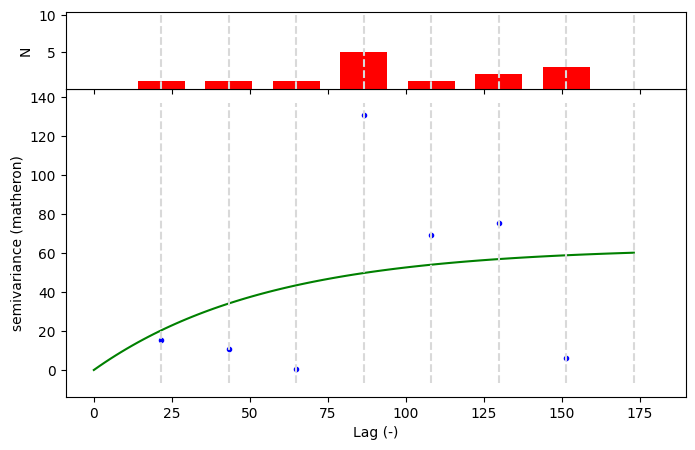

In [27]:
V1 = skg.Variogram(
    lyr1[['easting', 'northing']].values, 
    lyr1['Kh (m/day)'].values.flatten(), 
    maxlag=0.9, 
    n_lags=8, 
    normalize=False, 
    model='exponential'
    )

fig = V1.plot()

In [28]:
print(f"the correlation length based on the automatic data (poor) fitting is: {V1.describe()['effective_range']} meters")

the correlation length based on the automatic data (poor) fitting is: 166.11090288613792 meters


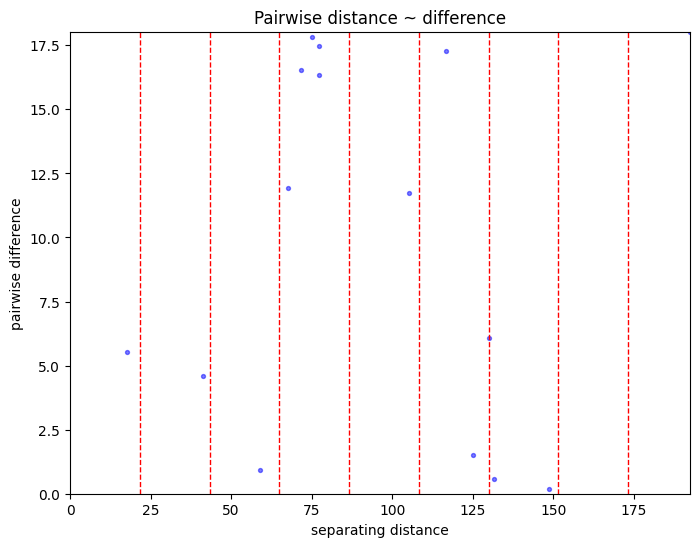

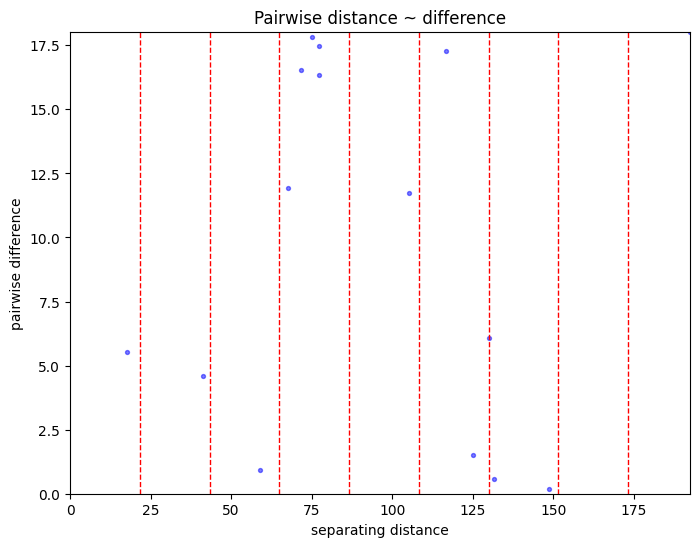

In [29]:
V1.distance_difference_plot(show=False)

In [30]:
ok1 = skg.OrdinaryKriging(V1, min_points=1, mode='exact')
x = lyr1[['easting', 'northing']].values[:, 0]
y = lyr1[['easting', 'northing']].values[:, 1]
xx, yy = np.mgrid[x.min():x.max():200j, y.min():y.max():200j]
field1 = ok1.transform(xx.flatten(), yy.flatten()).reshape(xx.shape)
s2 = ok1.sigma.reshape(xx.shape)

In [31]:
interpolator = RegularGridInterpolator(
    (xx[:, 0], yy[0, :]), 
    field1, 
    method='nearest', 
    bounds_error=False, 
    #fill_value=10.848392, 
    fill_value=None, 
    )
sample_coords1 = np.column_stack([df_pp1['x'].values, df_pp1['y'].values])
sampled_values1 = interpolator(sample_coords1)

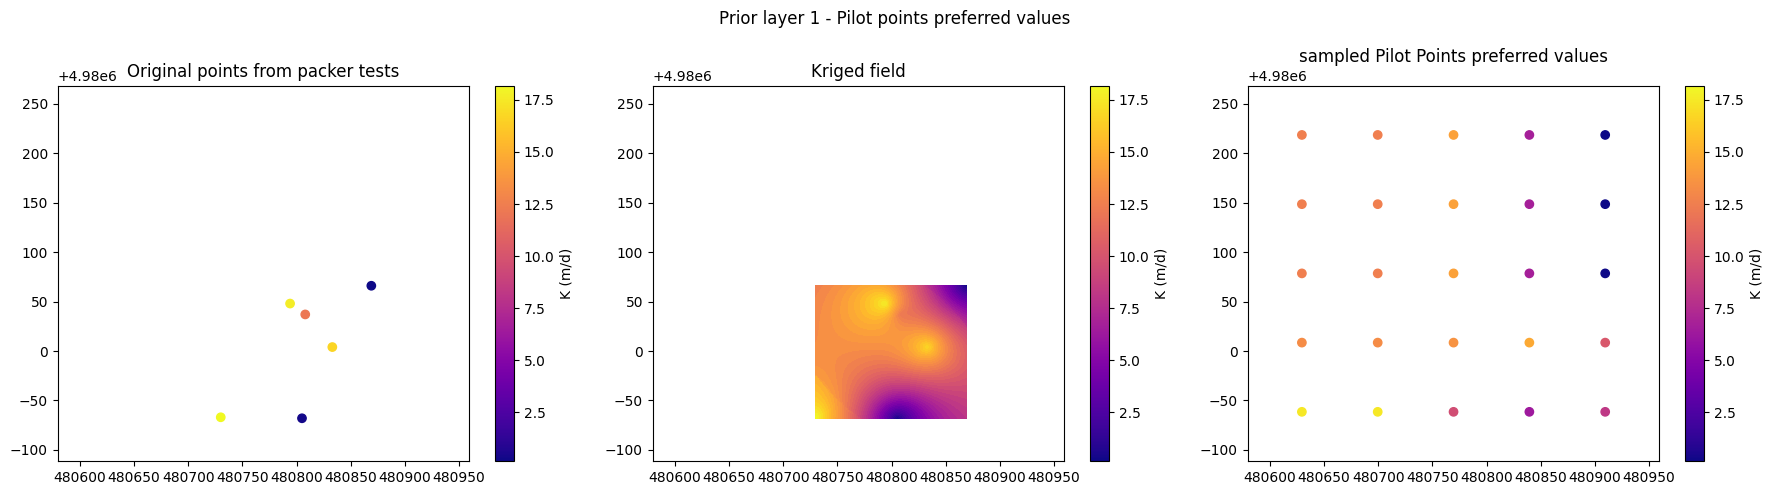

In [32]:
x_min, x_max = df_pp1['x'].min() - 50, df_pp1['x'].max() + 50
y_min, y_max = df_pp1['y'].min() - 50, df_pp1['y'].max() + 50

vmin = min(lyr1['Kh (m/day)'].min(), field1.min(), sampled_values1.min())
vmax = max(lyr1['Kh (m/day)'].max(), field1.max(), sampled_values1.max())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#original data packer test
sc1 = ax1.scatter(
    lyr1['easting'], lyr1['northing'], 
    c=lyr1['Kh (m/day)'], 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax1.set_title('Original points from packer tests')
plt.colorbar(sc1, ax=ax1, label='K (m/d)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

#kriged field
sc2 = ax2.contourf(
    np.linspace(x.min(),x.max(),200), 
    np.linspace(y.min(),y.max(),200), 
    field1.T, 
    origin='lower', cmap='plasma', 
    vmin=vmin, vmax=vmax, 
    levels=50
    )
ax2.set_title('Kriged field')
plt.colorbar(sc1, ax=ax2, label='K (m/d)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

sc3 = ax3.scatter(
    df_pp1['x'], df_pp1['y'], 
    #c=df_pp1['parval1'], 
    c=sampled_values1, 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax3.set_title('sampled Pilot Points preferred values')
plt.colorbar(sc3, ax=ax3, label='K (m/d)')
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Plot interpolated points
fig.suptitle('Prior layer 1 - Pilot points preferred values')

plt.tight_layout()
plt.show()

asserting pilot point file was created

In [33]:
pp1_file = os.path.join(template_ws, "k_layer1_inst0pp.dat")
assert os.path.exists(pp1_file)

In [34]:
df_pp1.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints


updating initial value + parameter bounds based on prior data uncertainty

In [35]:
df_pp1['parval1'] = sampled_values1
par_bnd_len = np.std(np.log(lyr1['Kh (m/day)'].values))*4
parlbnd = np.log(df_pp1['parval1'].values) - (par_bnd_len/2)
parubnd = np.log(df_pp1['parval1'].values) + (par_bnd_len/2)
df_pp1['parlbnd'] = 10**parlbnd
df_pp1['parubnd'] = 10**parubnd

In [36]:
df_pp1.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,12.543329,0,35,35,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.031977,log,3.577192e+06,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,12.543329,0,35,105,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.031977,log,3.577192e+06,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,14.245595,0,35,175,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.042864,log,4.795136e+06,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,6.692150,0,35,245,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.007526,log,8.419539e+05,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,0.156380,0,35,315,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.000001,log,1.475322e+02,1.0,pilotpoints


In [37]:
len(df_pp1)

25

pilot points locations

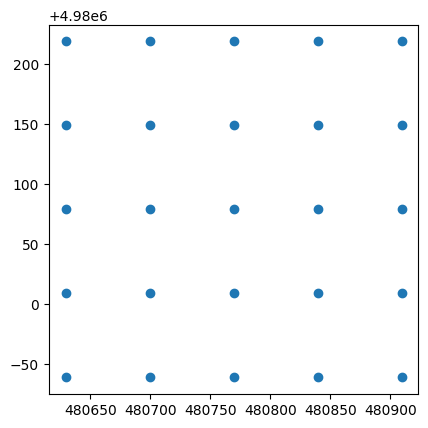

In [38]:
fig, ax = plt.subplots()
ax.set_aspect("equal")
#ax.pcolormesh(sr.xcentergrid, sr.ycentergrid, ib)
ax.scatter(df_pp1.x, df_pp1.y)

adding parameter to layer 2 (BPP): constant K for now

In [39]:
df_pp2 = pf.add_parameters(
    'k_layer2.txt', #check that
    par_type='pilotpoints', 
    par_name_base="k_layer2", 
    #pargp="pg2", 
    #zone_array=ib, #to be added when inactivating some cells

    geostruct=pp_gs_2, #geostructure of the pilot points #for interpolate from pp to model grid 
    #USING THE SAME STRUCTURE AS LAYER 1 (ABOVE BPP)

    #lower_bound=0.01, upper_bound=1000, 
    #ult_ubound=1000, ult_lbound=0.001,
    pp_space='C:/Users/lima0055/Documents/MLAC-3D-HT/data/pilot-points-v1.shp', 
    )

2025-12-02 16:21:06.789418 transform was not passed, setting default transform to 'log'
2025-12-02 16:21:06.789418 starting: adding pilotpoints type m style parameters for file(s) ['k_layer2.txt']
2025-12-02 16:21:06.789418 starting: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:50.0,anisotropy:1.0,bearing:0.0

2025-12-02 16:21:06.789418 starting: loading array template\k_layer2.txt
2025-12-02 16:21:06.843690 finished: loading array template\k_layer2.txt took: 0:00:00.054272
2025-12-02 16:21:06.844703 loaded array 'mf6\k_layer2.txt' of shape (388, 388)
2025-12-02 16:21:06.949900 starting: writing array-style template file 'template\k_layer2_inst0_pilotpoints.csv.tpl'
2025-12-02 16:21:06.949900 starting: setting up pilot point parameters
2025-12-02 16:21:06.950902 WARNING: Directly passing 'pp_space' has been deprecated and will eventually be removed, please use pp_options['pp_space'] instead.
2025-12-02 16:21:06.950902 'use_pp_zones' not set in pp_opt

In [40]:
df_pp2.head()

,id,criteria,utme,utmn,name,x,y,parval1,zone,parnme,...,pp_filename,pargp,partype,partrans,parubnd,parlbnd,dercom,scale,offset,parchglim
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,1,between,480809.274,4980039.117,0,480809.273663,4.980039e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,2,between,480784.136,4980045.501,1,480784.135516,4.980046e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,3,between,480797.303,4980075.029,2,480797.303116,4.980075e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,4,between,480846.781,4980047.496,3,480846.781375,4.980047e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,5,between,480869.525,4980091.787,4,480869.525413,4.980092e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor


In [41]:
columns_to_export = ['name', 'x', 'y', 'zone', 'parval1'] 
df_pp2_subset = df_pp2[columns_to_export]

df_pp2_subset.to_csv(
    os.path.join(template_ws, 'k_layer2_inst0pp.dat'), 
    sep=' ',          #space delimiter
    index=False,
    header=False
)

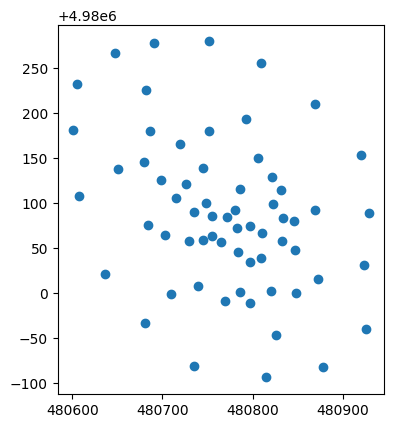

In [42]:
fig, ax = plt.subplots()
ax.set_aspect("equal")
#ax.pcolormesh(sr.xcentergrid, sr.ycentergrid, ib)
ax.scatter(df_pp2.x, df_pp2.y)

importing packer + slug test data for layer 2 (BPP)

In [43]:
df_packers = pd.read_excel('../../../data/MODFLOW_layers_priors.xlsx')
lyr2 = df_packers[df_packers['layer'] == 2]
lyr2 = lyr2.dropna(subset=['easting', 'northing', 'Kh (m/day)']) #dropping nans
#lyr2 = lyr2.drop(7) #dropping PZ-2, data not reliable
lyr2 #packer data for layer 1

,borehole,northing,easting,layer,Kh (m/day),method,source,notes,old value
1,PW-1,4980066,480869,2,8.500000,packer + pumping test,"packer test (PEER, 1999)",NaN,NaN
4,PW-2,4980048,480794,2,24.969600,packer test,"packer test (PEER, 1999)",NaN,NaN
7,PZ-2,4980037,480808,2,19.100000,pumping test,"pumping test (PEER, 1999)",NaN,NaN
10,94-02,4980038,480890,2,7.092215,packer test,"packer test (CNA, 1997)","average between (6.46046, 7.72397)",NaN
13,94-07,4980198,480782,2,26.408272,packer test,"packer test (CNA, 1997)","average between (18.10218, 28.69549, 38.02080, 20.81462)",NaN
16,94-08,4979864,480711,2,30.443695,packer test,"packer test (CNA, 1997)","average between (24.31918, 36.56821)",NaN
19,94-09,4979900,480919,2,23.326910,packer test,"packer test (CNA, 1997)",NaN,NaN
22,94-10,4979932,480805,2,51.195490,packer test,"packer test (CNA, 1997)",NaN,NaN
25,94-11,4980004,480833,2,16.897960,packer test,"packer test (CNA, 1997)",NaN,NaN
28,94-16,4979933,480730,2,12.193260,packer test,"packer test (CNA, 1997)",NaN,NaN


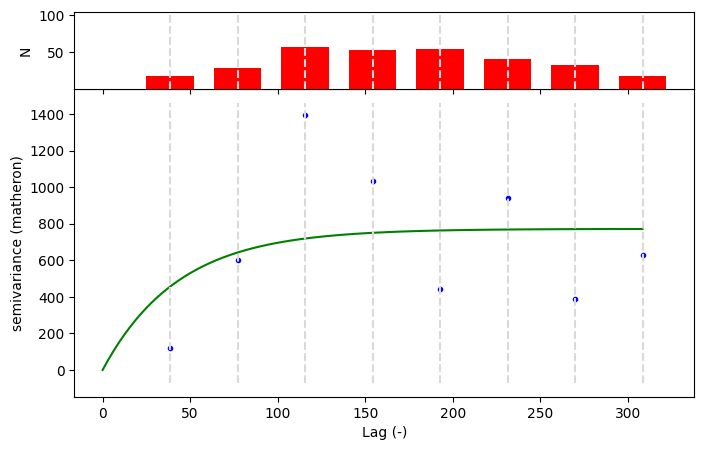

In [44]:
V2 = skg.Variogram(
    lyr2[['easting', 'northing']].values, 
    lyr2['Kh (m/day)'].values.flatten(), 
    maxlag=0.7, 
    n_lags=8, 
    normalize=False, 
    model='exponential'
    )

fig = V2.plot()

In [45]:
print(f"the correlation length based on the automatic data (poor) fitting is: {V2.describe()['effective_range']} meters")

the correlation length based on the automatic data (poor) fitting is: 129.4944223063351 meters


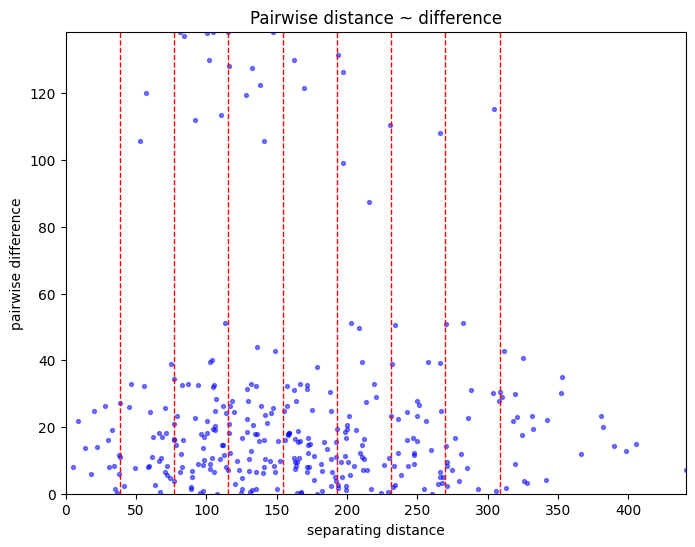

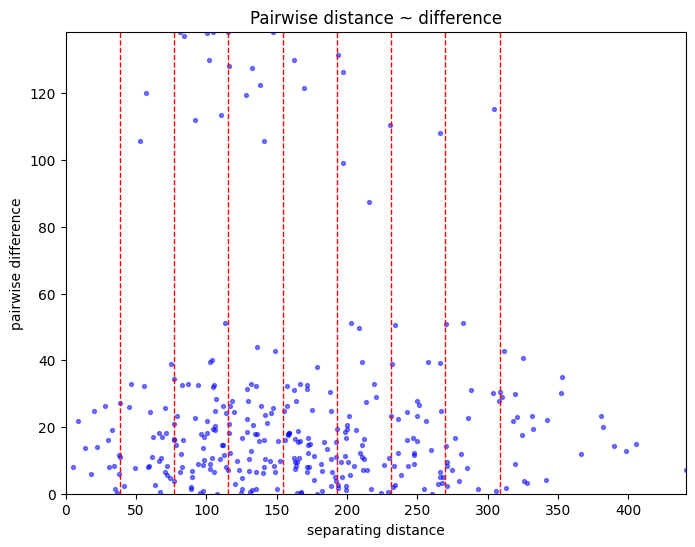

In [46]:
V2.distance_difference_plot(show=False)

In [47]:
ok2 = skg.OrdinaryKriging(V2, min_points=1, mode='exact')
x = lyr2[['easting', 'northing']].values[:, 0]
y = lyr2[['easting', 'northing']].values[:, 1]
xx, yy = np.mgrid[x.min():x.max():200j, y.min():y.max():200j]
field2 = ok2.transform(xx.flatten(), yy.flatten()).reshape(xx.shape)
s2 = ok2.sigma.reshape(xx.shape)

In [48]:
interpolator = RegularGridInterpolator(
    (xx[:, 0], yy[0, :]), 
    field2, 
    method='nearest', 
    bounds_error=False, 
    #fill_value=10.848392, 
    fill_value=None, 
    )
sample_coords2 = np.column_stack([df_pp2['x'].values, df_pp2['y'].values])
sampled_values2 = interpolator(sample_coords2)

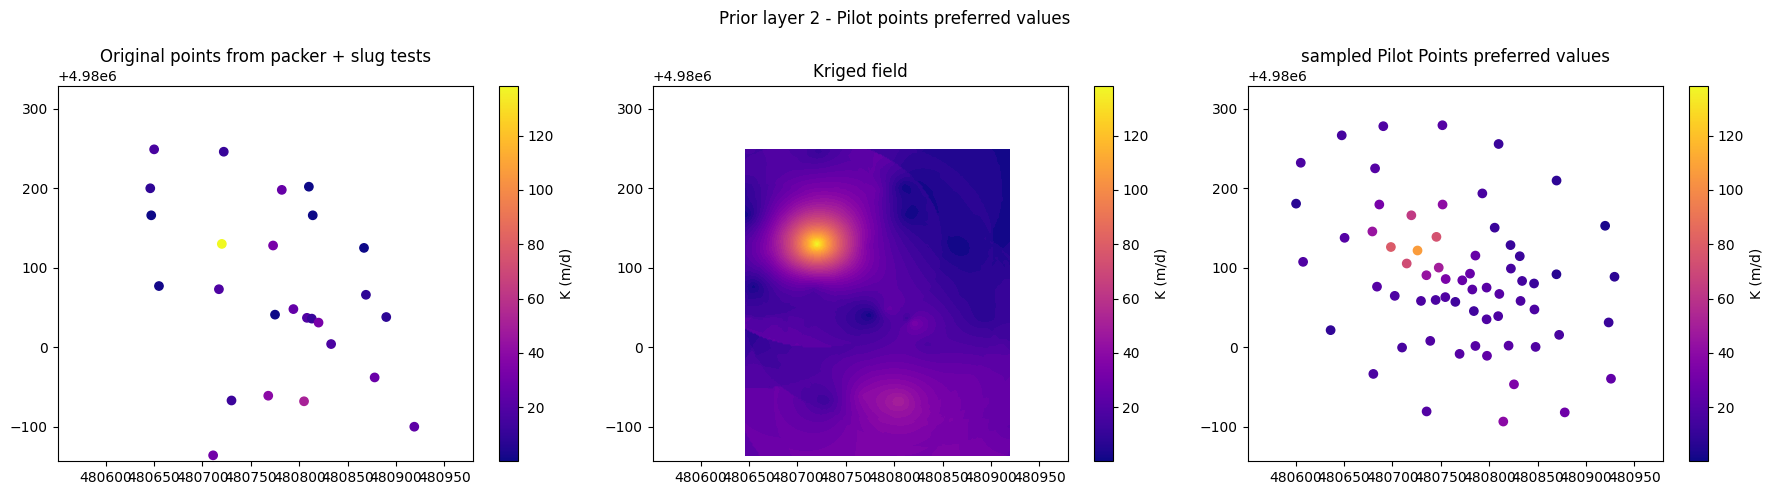

In [49]:
x_min, x_max = df_pp2['x'].min() - 50, df_pp2['x'].max() + 50
y_min, y_max = df_pp2['y'].min() - 50, df_pp2['y'].max() + 50

vmin = min(lyr2['Kh (m/day)'].min(), field2.min(), sampled_values2.min())
vmax = max(lyr2['Kh (m/day)'].max(), field2.max(), sampled_values2.max())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#original data packer test
sc1 = ax1.scatter(
    lyr2['easting'], lyr2['northing'], 
    c=lyr2['Kh (m/day)'], 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax1.set_title('Original points from packer + slug tests')
plt.colorbar(sc1, ax=ax1, label='K (m/d)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

#kriged field
sc2 = ax2.contourf(
    np.linspace(x.min(),x.max(),200), 
    np.linspace(y.min(),y.max(),200), 
    field2.T, 
    origin='lower', cmap='plasma', 
    vmin=vmin, vmax=vmax, 
    levels=50
    )
ax2.set_title('Kriged field')
plt.colorbar(sc1, ax=ax2, label='K (m/d)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

sc3 = ax3.scatter(
    df_pp2['x'], df_pp2['y'], 
    #c=df_pp2['parval1'], 
    c=sampled_values2, 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax3.set_title('sampled Pilot Points preferred values')
plt.colorbar(sc3, ax=ax3, label='K (m/d)')
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Plot interpolated points
fig.suptitle('Prior layer 2 - Pilot points preferred values')

plt.tight_layout()
plt.show()

In [50]:
pp2_file = os.path.join(template_ws, "k_layer2_inst0pp.dat")
assert os.path.exists(pp2_file)

In [51]:
df_pp2.head()

,id,criteria,utme,utmn,name,x,y,parval1,zone,parnme,...,pp_filename,pargp,partype,partrans,parubnd,parlbnd,dercom,scale,offset,parchglim
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,1,between,480809.274,4980039.117,0,480809.273663,4.980039e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,2,between,480784.136,4980045.501,1,480784.135516,4.980046e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,3,between,480797.303,4980075.029,2,480797.303116,4.980075e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,4,between,480846.781,4980047.496,3,480846.781375,4.980047e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,5,between,480869.525,4980091.787,4,480869.525413,4.980092e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor


In [52]:
df_pp2['parval1'] = sampled_values2
par_bnd_len = np.std(np.log(lyr2['Kh (m/day)'].values))*4
parlbnd = np.log(df_pp2['parval1'].values) - (par_bnd_len/2)
parubnd = np.log(df_pp2['parval1'].values) + (par_bnd_len/2)
df_pp2['parlbnd'] = 10**parlbnd
df_pp2['parubnd'] = 10**parubnd
df_pp2['zone'] = 2

In [53]:
df_pp2.head()

,id,criteria,utme,utmn,name,x,y,parval1,zone,parnme,...,pp_filename,pargp,partype,partrans,parubnd,parlbnd,dercom,scale,offset,parchglim
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,1,between,480809.274,4980039.117,0,480809.273663,4.980039e+06,17.540721,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.338608e+07,0.040031,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,2,between,480784.136,4980045.501,1,480784.135516,4.980046e+06,13.825451,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,7.738191e+06,0.023141,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,3,between,480797.303,4980075.029,2,480797.303116,4.980075e+06,21.623789,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,2.167317e+07,0.064814,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,4,between,480846.781,4980047.496,3,480846.781375,4.980047e+06,16.912463,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.230776e+07,0.036806,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,5,between,480869.525,4980091.787,4,480869.525413,4.980092e+06,6.484294,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.353665e+06,0.004048,1,1.0,0.0,factor


In [54]:
len(df_pp2)

64

Adding parameter to layer 3: pilot points

In [55]:
#starting by getting array of idomain for the layer 0. this contain information of inactive cell to avoid placing pilot points
#ib3 = gwf.dis.idomain.array[2]
#plt.imshow(ib3)

In [56]:
df_pp3 = pf.add_parameters(
    'k_layer3.txt', #check that
    par_type='pilotpoints', 
    par_name_base="k_layer3", 
    #pargp="hk0", 
    #zone_array=ib, #to be added when inactivating some cells

    geostruct=pp_gs, #geostructure of the pilot points #for interpolate from pp to model grid 
    #USING THE SAME STRUCTURE AS LAYER 1 (ABOVE BPP)

    #lower_bound=0.01, upper_bound=1000, 
    #ult_ubound=1000, ult_lbound=0.001,
    pp_space=70
)

2025-12-02 16:21:30.632900 transform was not passed, setting default transform to 'log'
2025-12-02 16:21:30.632900 starting: adding pilotpoints type m style parameters for file(s) ['k_layer3.txt']
2025-12-02 16:21:30.632900 finished: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:200.0,anisotropy:1.0,bearing:0.0
 took: 0:00:47.962968
2025-12-02 16:21:30.632900 starting: loading array template\k_layer3.txt
2025-12-02 16:21:30.669870 finished: loading array template\k_layer3.txt took: 0:00:00.036970
2025-12-02 16:21:30.669870 loaded array 'mf6\k_layer3.txt' of shape (388, 388)
2025-12-02 16:21:30.847490 starting: writing array-style template file 'template\k_layer3_inst0_pilotpoints.csv.tpl'
2025-12-02 16:21:30.847490 starting: setting up pilot point parameters
2025-12-02 16:21:30.847490 WARNING: Directly passing 'pp_space' has been deprecated and will eventually be removed, please use pp_options['pp_space'] instead.
2025-12-02 16:21:30.847490 'use_pp_zo

In [57]:
df_pp3.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints


Importing packer test data for layer 3

In [58]:
df_packers = pd.read_excel('../../../data/MODFLOW_layers_priors.xlsx')
lyr3 = df_packers[df_packers['layer'] == 3]
lyr3 = lyr3.dropna(subset=['easting', 'northing', 'Kh (m/day)']) #dropping nans
lyr3 = lyr3.drop(8) #dropping PZ-2, data not reliable
lyr3 #packer data for layer 1

,borehole,northing,easting,layer,Kh (m/day),method,source,notes,old value
2,PW-1,4980066,480869,3,0.042080,packer test,"packer test (PEER, 1999)",NaN,NaN
11,94-02,4980038,480890,3,0.209863,packer test,"packer test (CNA, 1997)","average between (0.37042, 0.17790, 0.15445, 0.13668)",NaN
14,94-07,4980198,480782,3,0.237867,packer test,"packer test (CNA, 1997)","average between (0.27337, 0.23365, 0.20658)",NaN
17,94-08,4979864,480711,3,0.288900,packer test,"packer test (CNA, 1997)","average between (0.30866, 0.42640, 0.13164)",NaN
20,94-09,4979900,480919,3,3.274515,packer test,"packer test (CNA, 1997)","average between (12.30757, 0.22225, 0.19762, 0.37062)",NaN
23,94-10,4979932,480805,3,0.149703,packer test,"packer test (CNA, 1997)","average between (0.16944, 0.14803, 0.13164)",NaN
26,94-11,4980004,480833,3,0.879843,packer test,"packer test (CNA, 1997)","average between (0.07402, 1.01561, 1.54990)",NaN
29,94-16,4979933,480730,3,0.458860,packer test,"packer test (CNA, 1997)","average between (1.51673, 0.11113, 0.10162, 0.10596)",NaN


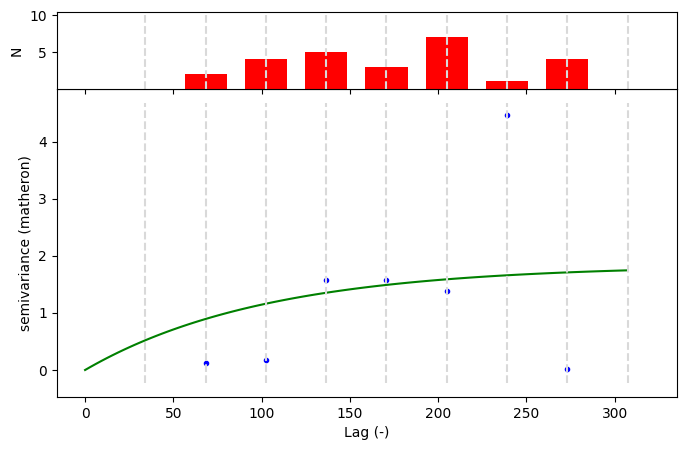

In [59]:
V3 = skg.Variogram(
    lyr3[['easting', 'northing']].values, 
    lyr3['Kh (m/day)'].values.flatten(), 
    maxlag=0.9, 
    n_lags=9, 
    normalize=False, 
    model='exponential'
    )

fig = V3.plot()

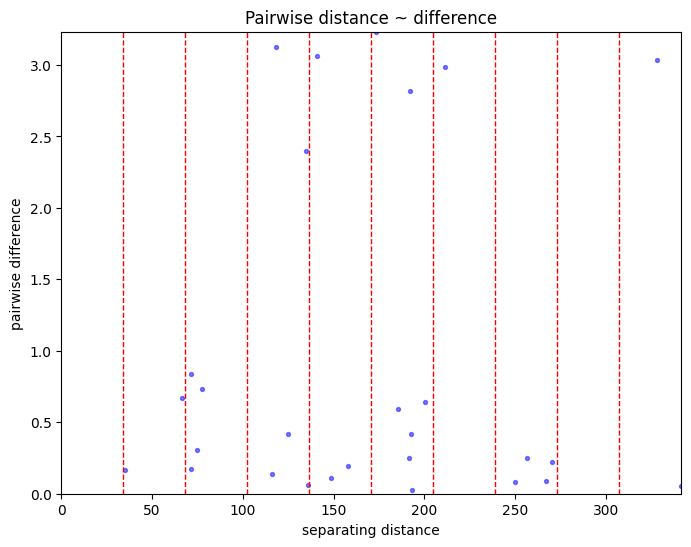

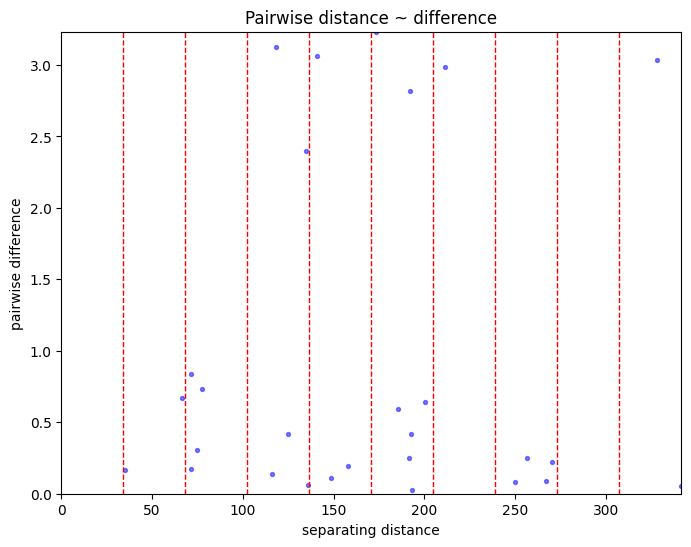

In [60]:
V3.distance_difference_plot(show=False)

In [61]:
print(f"the correlation length for layer 3 based on the packer test data is: {V3.describe()['effective_range']}")

the correlation length for layer 3 based on the packer test data is: 307.31672587088383


In [62]:
ok3 = skg.OrdinaryKriging(V3, min_points=1, mode='exact')
x = lyr3[['easting', 'northing']].values[:, 0]
y = lyr3[['easting', 'northing']].values[:, 1]
xx, yy = np.mgrid[x.min():x.max():200j, y.min():y.max():200j]
field3 = ok3.transform(xx.flatten(), yy.flatten()).reshape(xx.shape)
s2 = ok3.sigma.reshape(xx.shape)

In [63]:
interpolator = RegularGridInterpolator(
    (xx[:, 0], yy[0, :]), 
    field3, 
    method='nearest', 
    bounds_error=False, 
    #fill_value=10.848392, 
    fill_value=None, 
    )
sample_coords3 = np.column_stack([df_pp3['x'].values, df_pp3['y'].values])
sampled_values3 = interpolator(sample_coords3)

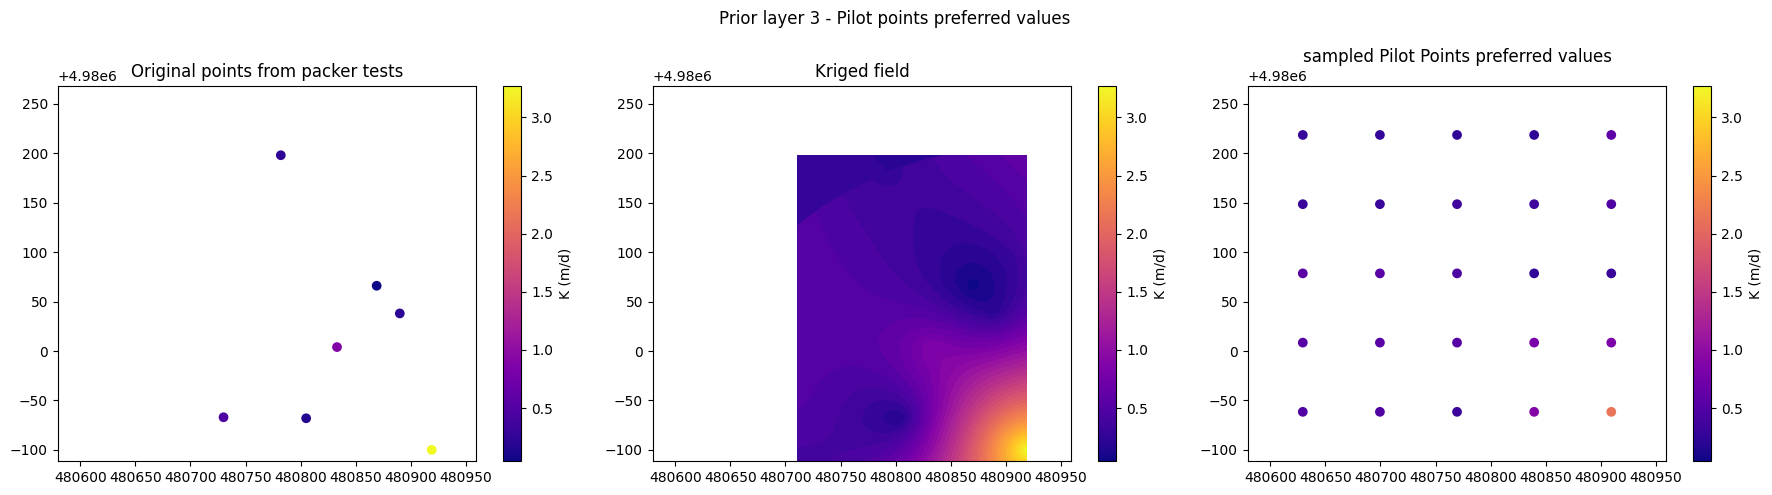

In [64]:
x_min, x_max = df_pp1['x'].min() - 50, df_pp1['x'].max() + 50
y_min, y_max = df_pp1['y'].min() - 50, df_pp1['y'].max() + 50

vmin = min(lyr3['Kh (m/day)'].min(), field3.min(), sampled_values3.min())
vmax = max(lyr3['Kh (m/day)'].max(), field3.max(), sampled_values3.max())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#original data packer test
sc1 = ax1.scatter(
    lyr3['easting'], lyr3['northing'], 
    c=lyr3['Kh (m/day)'], 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax1.set_title('Original points from packer tests')
plt.colorbar(sc1, ax=ax1, label='K (m/d)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

#kriged field
sc2 = ax2.contourf(
    np.linspace(x.min(),x.max(),200), 
    np.linspace(y.min(),y.max(),200), 
    field3.T, 
    origin='lower', cmap='plasma', 
    vmin=vmin, vmax=vmax, 
    levels=50
    )
ax2.set_title('Kriged field')
plt.colorbar(sc1, ax=ax2, label='K (m/d)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

sc3 = ax3.scatter(
    df_pp1['x'], df_pp1['y'], 
    #c=df_pp1['parval1'], 
    c=sampled_values3, 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax3.set_title('sampled Pilot Points preferred values')
plt.colorbar(sc3, ax=ax3, label='K (m/d)')
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Plot interpolated points
fig.suptitle('Prior layer 3 - Pilot points preferred values')

plt.tight_layout()
plt.show()

In [65]:
pp3_file = os.path.join(template_ws, "k_layer3_inst0pp.dat")
assert os.path.exists(pp3_file)

updating layer index, initial value, and pilot points parameter bounds

In [66]:
df_pp3['k'] = 2
df_pp3['parval1'] = sampled_values3
par_bnd_len = np.std(np.log(lyr3['Kh (m/day)'].values))*4
parlbnd = np.log(df_pp3['parval1'].values) - (par_bnd_len/2)
parubnd = np.log(df_pp3['parval1'].values) + (par_bnd_len/2)
df_pp3['parlbnd'] = 10**parlbnd
df_pp3['parubnd'] = 10**parubnd
df_pp3['zone'] = 3

In [67]:
df_pp3.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,3,0.281720,2,35,35,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.000215,log,13.619634,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,3,0.281720,2,35,105,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.000215,log,13.619634,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,3,0.248252,2,35,175,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.000161,log,10.178738,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,3,0.224927,2,35,245,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.000128,log,8.110130,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,3,0.589716,2,35,315,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.001177,log,74.626218,1.0,pilotpoints


Adding specific storage as a fitting parameter (constant ss for each layer)

In [68]:
df_ss1 = pf.add_parameters(
    "ss_layer1.txt", 
    par_type='constant', 
    par_name_base="ss_layer1", 
    pargp="ss_layer1", 
    initial_value=1e-5, 
    lower_bound=1e-6, ult_lbound=1e-6, 
    upper_bound=1, ult_ubound=1
)

2025-12-02 16:21:42.336127 transform was not passed, setting default transform to 'log'
2025-12-02 16:21:42.336127 starting: adding constant type m style parameters for file(s) ['ss_layer1.txt']
2025-12-02 16:21:42.336127 starting: loading array template\ss_layer1.txt
2025-12-02 16:21:42.367544 finished: loading array template\ss_layer1.txt took: 0:00:00.031417
2025-12-02 16:21:42.367544 loaded array 'mf6\ss_layer1.txt' of shape (388, 388)
2025-12-02 16:21:42.531258 starting: writing array-style template file 'template\ss_layer1_inst0_constant.csv.tpl'
2025-12-02 16:21:42.531258 starting: writing template file template\ss_layer1_inst0_constant.csv.tpl for ['ss_layer1_inst:0']
2025-12-02 16:21:43.486708 finished: writing template file template\ss_layer1_inst0_constant.csv.tpl for ['ss_layer1_inst:0'] took: 0:00:00.955450
2025-12-02 16:21:43.486708 starting: writing array-based template file 'template\ss_layer1_inst0_constant.csv.tpl'
2025-12-02 16:21:43.530985 finished: adding constant 

In [69]:
df_ss2 = pf.add_parameters(
    "ss_layer2.txt", 
    par_type='constant', 
    par_name_base="ss_layer2", 
    pargp="ss_layer2", 
    initial_value=1e-5, 
    lower_bound=1e-6, ult_lbound=1e-6, 
    upper_bound=1, ult_ubound=1
)

2025-12-02 16:21:43.550753 transform was not passed, setting default transform to 'log'
2025-12-02 16:21:43.550753 starting: adding constant type m style parameters for file(s) ['ss_layer2.txt']
2025-12-02 16:21:43.550753 starting: loading array template\ss_layer2.txt
2025-12-02 16:21:43.598572 finished: loading array template\ss_layer2.txt took: 0:00:00.047819
2025-12-02 16:21:43.598572 loaded array 'mf6\ss_layer2.txt' of shape (388, 388)
2025-12-02 16:21:43.736459 starting: writing array-style template file 'template\ss_layer2_inst0_constant.csv.tpl'
2025-12-02 16:21:43.736459 starting: writing template file template\ss_layer2_inst0_constant.csv.tpl for ['ss_layer2_inst:0']
2025-12-02 16:21:44.722447 finished: writing template file template\ss_layer2_inst0_constant.csv.tpl for ['ss_layer2_inst:0'] took: 0:00:00.985988
2025-12-02 16:21:44.722447 starting: writing array-based template file 'template\ss_layer2_inst0_constant.csv.tpl'
2025-12-02 16:21:44.785803 finished: adding constant 

In [70]:
df_ss3 = pf.add_parameters(
    "ss_layer3.txt", 
    par_type='constant', 
    par_name_base="ss_layer3", 
    pargp="ss_layer3", 
    initial_value=1e-5, 
    lower_bound=1e-6, ult_lbound=1e-6, 
    upper_bound=1, ult_ubound=1
)

2025-12-02 16:21:44.824641 transform was not passed, setting default transform to 'log'
2025-12-02 16:21:44.824641 starting: adding constant type m style parameters for file(s) ['ss_layer3.txt']
2025-12-02 16:21:44.824641 starting: loading array template\ss_layer3.txt
2025-12-02 16:21:44.896869 finished: loading array template\ss_layer3.txt took: 0:00:00.072228
2025-12-02 16:21:44.896869 loaded array 'mf6\ss_layer3.txt' of shape (388, 388)
2025-12-02 16:21:45.069714 starting: writing array-style template file 'template\ss_layer3_inst0_constant.csv.tpl'
2025-12-02 16:21:45.069714 starting: writing template file template\ss_layer3_inst0_constant.csv.tpl for ['ss_layer3_inst:0']
2025-12-02 16:21:46.003801 finished: writing template file template\ss_layer3_inst0_constant.csv.tpl for ['ss_layer3_inst:0'] took: 0:00:00.934087
2025-12-02 16:21:46.003801 starting: writing array-based template file 'template\ss_layer3_inst0_constant.csv.tpl'
2025-12-02 16:21:46.051238 finished: adding constant 

In [71]:
df_ss1

,parnme,parval1,pargp,tpl_filename,input_filename,partype,partrans,parubnd,parlbnd,dercom,scale,offset,parchglim
pname:ss_layer1_inst:0_ptype:cn_pstyle:m,pname:ss_layer1_inst:0_ptype:cn_pstyle:m,0.00001,ss_layer1,template\ss_layer1_inst0_constant.csv.tpl,template\mult\ss_layer1_inst0_constant.csv,constant,log,1,0.000001,1,1.0,0.0,factor


Adding mf6 to the command script

In [72]:
pf.mod_sys_cmds.append("mf6") #do this only once
pf.mod_sys_cmds

['mf6']

adding the processing MODFLOW output in the PEST running script. 

This processing script reads the MODFLOW simulation output (heads for all well in all simulation time steps), and sample heads only for desired times (i.e. times that we have field data) using interpolation, then overwrites the heads.csv (MODFLOW output) used to compared with the observation data added to the PEST control file.

In [73]:
pf.add_py_function("helpers.py","process_heads_csv()",is_pre_cmd=False)

building pst

In [74]:
pst = pf.build_pst()

2025-12-02 16:21:46.157557 starting: Converting parameters to shortnames
2025-12-02 16:21:46.157557 starting: Renaming parameters for shortnames
2025-12-02 16:21:50.625273 finished: Renaming parameters for shortnames took: 0:00:04.467716
2025-12-02 16:21:50.641033 finished: Converting parameters to shortnames took: 0:00:04.483476
2025-12-02 16:21:50.643060 starting: Converting observations to shortnames
2025-12-02 16:21:50.649116 starting: Renaming observations for shortnames
2025-12-02 16:21:55.597557 finished: Renaming observations for shortnames took: 0:00:04.948441
2025-12-02 16:21:55.621597 finished: Converting observations to shortnames took: 0:00:04.978537
noptmax:0, npar_adj:117, nnz_obs:120
2025-12-02 16:21:55.692754 forward_run line:pyemu.os_utils.run(r'mf6')



Changing observation groups based on layers

In [75]:
condition1 = pst.observation_data['longname'].str.contains('pw2-1|pz1-1', case=False, regex=True)
condition3 = pst.observation_data['longname'].str.contains('pz1-3', case=False, regex=True)
condition2 = [not element for element in condition1.values + condition3.values]
pst.observation_data.loc[condition1, 'obgnme'] = 'ob0'
pst.observation_data.loc[condition2, 'obgnme'] = 'ob1'
pst.observation_data.loc[condition3, 'obgnme'] = 'ob2'

In [76]:
pst.observation_data.head()

,obsnme,obsval,weight,obgnme,longname,shortname,oglong,oname,otype,time,usecol
ob0,ob0,0.010999,1.0,ob1,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,ob0,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p,pmw-3,lst,0.010417,head
ob1,ob1,0.022082,1.0,ob1,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,ob1,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p,pmw-3,lst,0.020833,head
ob2,ob2,0.037808,1.0,ob1,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,ob2,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p,pmw-3,lst,0.041667,head
ob3,ob3,0.049898,1.0,ob1,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,ob3,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p,pmw-3,lst,0.0625,head
ob4,ob4,0.006916,1.0,ob1,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,ob4,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow23p,pmw-3,lst,0.010417,head


Changing forward_run.py file to move to each simulation folder and run MODFLOW in there, 

This is, for now, MODFLOW is running sequentially

In [77]:
filename = os.path.join(template_ws, 'forward_run.py')
search_code = "    pyemu.os_utils.run(r'mf6')\n"

paths = [os.path.basename(os.path.normpath(p)) for p in path]

new_code = ''
for i in paths: 
    new_code = new_code + f"    os.chdir('{i}') \n    pyemu.os_utils.run(r'mf6') #running MODFLOW in {i} \n    os.chdir('..')\n"

In [78]:
from helpers import replace_forward_run

replace_forward_run(filename, search_code, new_code)

checking parameter groups and data

In [79]:
pst.parameter_groups

,pargpnme,inctyp,derinc,derinclb,forcen,derincmul,dermthd,splitthresh,splitreldiff,splitaction
pargpnme,,,,,,,,,,
pg1,pg1,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg0,pg0,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg2,pg2,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg3,pg3,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg4,pg4,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg5,pg5,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller


In [80]:
pst.parameter_data.sample(5)

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,longname,shortname,pglong,i,inst,j,pname,pstyle,ptype,x,y,zone
p94,p94,log,factor,0.298380,0.000245,1.554602e+01,pg2,1.0,0.0,1,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:105_j:35_zone:1,p94,k_layer3_inst:0,105,0,35,k,m,pp,NaN,NaN,1
p86,p86,log,factor,39.214564,0.255223,8.534469e+07,pg1,1.0,0.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480814.56_y:4979906.51_zone:1,p86,k_layer2_inst:0,NaN,0,NaN,k,m,pp,480814.56,4979906.51,1
p87,p87,log,factor,29.206750,0.129501,4.330401e+07,pg1,1.0,0.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480878.11_y:4979918.01_zone:1,p87,k_layer2_inst:0,NaN,0,NaN,k,m,pp,480878.11,4979918.01,1
p1,p1,log,factor,12.543329,0.031977,3.577192e+06,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,p1,k_layer1_inst:0,35,0,105,k,m,pp,NaN,NaN,1
p28,p28,log,factor,16.912463,0.036806,1.230776e+07,pg1,1.0,0.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,p28,k_layer2_inst:0,NaN,0,NaN,k,m,pp,480846.78,4980047.50,1


## checking phimlim for investigation of minimum phi

In [81]:
pst.reg_data.phimlim

'1.0e-10'

minimum phi should be equal to the number of non-zero weighted observations

THIS ASSUMES THAT ALL MODEL-TO-MEASUREMENT MISFIT IS DUE TO MEASUREMENT UNCERTAINTY. In practice model error usually plays a larger role

In [82]:
pst.nnz_obs

120

aasigning PHILIM equal to the number of non-zero weighted observations

In [83]:
#pst.reg_data.phimlim = pst.nnz_obs
pst.reg_data.phimlim

'1.0e-10'

When changing PHIMLIM, we must also change PHIMACCEPT. this is the level of acceptable "measurement objective function".

If PEST achieves PHIMLIM, it will then attempt to minimize the regularization objective function, whiilst maintaining the measurement objective function below PHIMACCEPT

In [84]:
#setting PHIMACCEPT 10% higher than PHIMLIM
pst.reg_data.phimaccept = float(pst.reg_data.phimlim) * 1.1
pst.reg_data.phimaccept

1.1000000000000001e-10

changing PESTMODE to regularization

In [85]:
pst.control_data.pestmode = 'regularization'
pst.control_data.pestmode

'regularization'

In [86]:
pst.control_data.rlambda1

20.0

In [87]:
pst.control_data.rlambda1 = 1.0
pst.control_data.rlambda1

np.float64(1.0)

updating the maximum number of PEST iteration

In [88]:
pst.control_data.noptmax = 0
pst.control_data.noptmax

np.int32(0)

In [89]:
print(f'there are {pst.nobs} field observation')

there are 120 field observation


Checking input and output model files

In [90]:
pst.model_input_data

,pest_file,model_file
k_layer1_inst0pp.dat.tpl,k_layer1_inst0pp.dat.tpl,k_layer1_inst0pp.dat
k_layer2_inst0pp.dat.tpl,k_layer2_inst0pp.dat.tpl,k_layer2_inst0pp.dat
k_layer3_inst0pp.dat.tpl,k_layer3_inst0pp.dat.tpl,k_layer3_inst0pp.dat
ss_layer1_inst0_constant.csv.tpl,ss_layer1_inst0_constant.csv.tpl,mult\ss_layer1_inst0_constant.csv
ss_layer2_inst0_constant.csv.tpl,ss_layer2_inst0_constant.csv.tpl,mult\ss_layer2_inst0_constant.csv
ss_layer3_inst0_constant.csv.tpl,ss_layer3_inst0_constant.csv.tpl,mult\ss_layer3_inst0_constant.csv


In [91]:
pst.model_output_data

,pest_file,model_file
PMW-3_heads.csv.ins,PMW-3_heads.csv.ins,PMW-3_heads.csv
PMW-6_heads.csv.ins,PMW-6_heads.csv.ins,PMW-6_heads.csv


Adding priors

In [92]:
pst.prior_information #no prior info up to now

,pilbl,obgnme,equation,weight


In [93]:
pst.parameter_groups

,pargpnme,inctyp,derinc,derinclb,forcen,derincmul,dermthd,splitthresh,splitreldiff,splitaction
pargpnme,,,,,,,,,,
pg1,pg1,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg0,pg0,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg2,pg2,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg3,pg3,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg4,pg4,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg5,pg5,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller


adding preferred-value equations, currently only for layer 1 and 2

In [94]:
#applying preferred value regularization on all parameters
pyemu.helpers.zero_order_tikhonov(
    pst, parbounds=True, #using parameter bounds to specify prior information equation weights
    par_groups=['pg0', 'pg1', 'pg2'], #adding preferred-value only for pp in layer 1 and 3
    ) #setting up preferred-value regularization in the pest control file


In [95]:
pst.prior_information.sample(5)

,pilbl,equation,obgnme,weight
pilbl,,,,
p64,p64,1.0 * log(p64) = 1.276658E+00,regulpg1,0.117312
p103,p103,1.0 * log(p103) = -5.158872E-01,regulpg2,0.208246
p38,p38,1.0 * log(p38) = 1.332019E+00,regulpg1,0.117312
p22,p22,1.0 * log(p22) = 9.800248E-01,regulpg0,0.124244
p83,p83,1.0 * log(p83) = 9.532518E-01,regulpg1,0.117312


In [96]:
#pst.pestpp_options.pop('n_iter_base')
#pst.pestpp_options.pop('n_iter_super')

overwritting pst file

In [97]:
pst.write(os.path.join(template_ws, 'mf6.pst'),version=1)

noptmax:0, npar_adj:117, nnz_obs:120


setting up agents for running PEST in parallel

In [98]:
#number of cores availables
psutil.cpu_count(logical=False)

10

In [99]:
#setting the number of workers
num_workers = 9

In [100]:
#run-manager directory folder (where the manager will be running), 
#outcomes of PEST will be recorded here in a different location than template_ws to avoid mistakes
m_d = 'master_pp'

when running from jupyter notebook slow things down a lot, it is better as the model get complex to run from command lines which is faster and more efficient

Starting workers and running PEST

In [101]:
pyemu.os_utils.start_workers(template_ws, # folder which contains the "template" PEST dataset
                            'pestpp-glm', #PEST software version we want to run
                            'mf6.pst', #PEST control file 
                            num_workers=num_workers, #how many agents to deploy
                            worker_root='.', #where to deploy the agent directories; relative to where python is running
                            master_dir=m_d, #manager directory where it will be running
                            verbose=True,
                            )

2025-12-02 16:21:56,266 - MainProcess - INFO - Reserved port 4151 for process 20156


master:pestpp-glm mf6.pst /h :4151 in master_pp
worker:pestpp-glm mf6.pst /h localhost:4151 in .\worker_0
worker:pestpp-glm mf6.pst /h localhost:4151 in .\worker_1
worker:pestpp-glm mf6.pst /h localhost:4151 in .\worker_2
worker:pestpp-glm mf6.pst /h localhost:4151 in .\worker_3
worker:pestpp-glm mf6.pst /h localhost:4151 in .\worker_4
worker:pestpp-glm mf6.pst /h localhost:4151 in .\worker_5
worker:pestpp-glm mf6.pst /h localhost:4151 in .\worker_6
worker:pestpp-glm mf6.pst /h localhost:4151 in .\worker_7
worker:pestpp-glm mf6.pst /h localhost:4151 in .\worker_8


Running PEST #old

In [102]:
#pyemu.os_utils.run('pestpp-glm PMW-6_mf6.pst', cwd=template_ws, verbose=True)

plotting results

In [103]:
df_obj = pd.read_csv(os.path.join(m_d, "mf6.iobj"),index_col=0)
# echo out the dataframe
df_obj

,model_runs_completed,total_phi,measurement_phi,regularization_phi,ob1,ob0,ob2,regulpg0,regulpg1,regulpg2
iteration,,,,,,,,,,
0,1,1.25942,1.25942,8.557180e-14,1.24141,0.010594,0.007422,2.145760e-14,6.344740e-14,6.668220e-16


array([<Axes: xlabel='iteration'>, <Axes: xlabel='iteration'>],
      dtype=object)

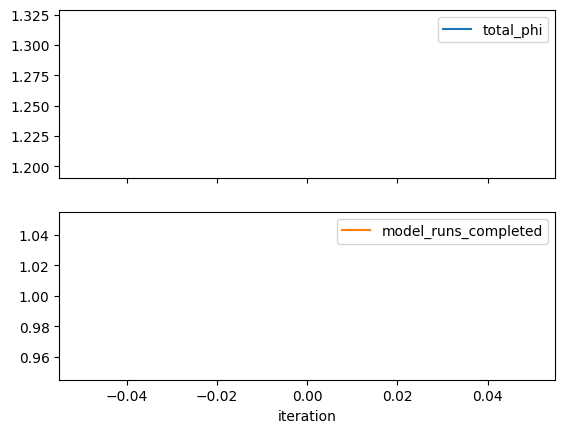

In [104]:
df_obj.loc[:,["total_phi","model_runs_completed"]].plot(subplots=True)

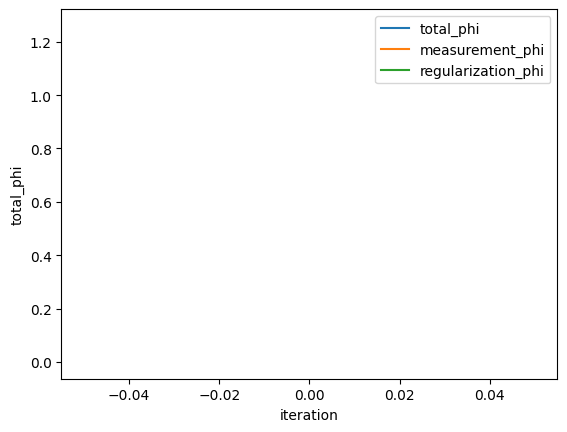

In [105]:
df_obj.plot(y=['total_phi','measurement_phi','regularization_phi'])
plt.ylabel('total_phi');

loading pst

In [106]:
pst = pyemu.Pst(os.path.join(m_d, 'mf6.pst'))

In [107]:
pst.phi

np.float64(1.2594229968101198)

Estimated K values:

In [108]:
pst.parrep(os.path.join(m_d, "mf6.par" ))
pst.write_input_files(pst_path=m_d)
pyemu.geostats.fac2real(os.path.join(m_d,"k_layer1_inst0pp.dat"),
                        factors_file=os.path.join(m_d,"k_layer1_inst0pp.fac"),
                        out_file=os.path.join(m_d,"k_layer1.txt"))

Updating parameter values from master_pp\mf6.par
parrep: updating noptmax to 0


'master_pp\\k_layer1.txt'

Layer 2 

In [109]:
pyemu.geostats.fac2real(os.path.join(m_d,"k_layer2_inst0pp.dat"),
                        factors_file=os.path.join(m_d,"k_layer2_inst0pp.fac"),
                        out_file=os.path.join(m_d,"k_layer2.txt"))

'master_pp\\k_layer2.txt'

In [110]:
pyemu.geostats.fac2real(os.path.join(m_d,"k_layer3_inst0pp.dat"),
                        factors_file=os.path.join(m_d,"k_layer1_inst0pp.fac"),
                        out_file=os.path.join(m_d,"k_layer3.txt"))

'master_pp\\k_layer3.txt'

In [111]:
pst.parameter_data.parval1

parnme
p0       12.543329
p1       12.543329
p2       14.245595
p3        6.692150
p4        0.156380
p5       12.543329
p6       12.543329
p7       14.245595
p8        6.692150
p9        0.156380
p10      12.543329
p11      12.543329
p12      14.245595
p13       6.692150
p14       0.156380
p15      13.198280
p16      13.198280
p17      13.584331
p18      14.717860
p19      10.166771
p20      17.421624
p21      17.421624
p22       9.550472
p23       6.332323
p24       8.200938
p25      17.540721
p26      13.825451
p27      21.623789
p28      16.912463
p29       6.484294
p30      15.040367
p31      17.795041
p32      11.497358
p33      20.639633
p34      18.367521
p35      13.735084
p36      17.423522
p37     106.992047
p38      21.479241
p39      15.555351
p40      11.671863
p41      26.645477
p42      18.475539
p43      26.509552
p44      17.321510
p45      18.382734
p46      74.378849
p47      78.853638
p48      33.426714
p49      20.714678
p50      48.815700
p51      62.906739
p52  

In [112]:
import seaborn as sns

<Axes: >

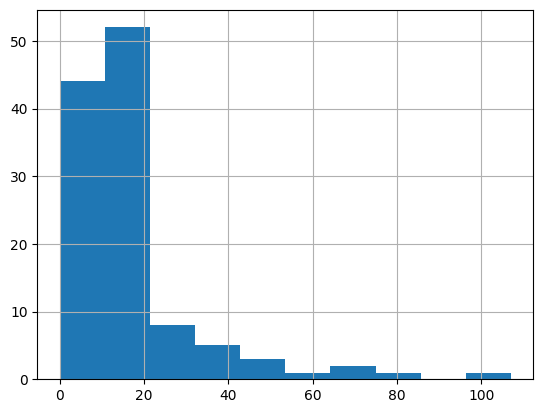

In [113]:
pst.parameter_data.parval1.hist()

In [114]:
pst.parameter_data.head()

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,extra,longname,i,inst,j,pname,pstyle,ptype,x,y,zone
parnme,,,,,,,,,,,,,,,,,,,,,
p0,p0,log,factor,12.543329,0.031977,3.577192e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,35,0,35,k,m,pp,NaN,NaN,1
p1,p1,log,factor,12.543329,0.031977,3.577192e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,35,0,105,k,m,pp,NaN,NaN,1
p2,p2,log,factor,14.245595,0.042864,4.795136e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,35,0,175,k,m,pp,NaN,NaN,1
p3,p3,log,factor,6.692150,0.007526,8.419539e+05,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,35,0,245,k,m,pp,NaN,NaN,1
p4,p4,log,factor,0.156380,0.000001,1.475322e+02,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,35,0,315,k,m,pp,NaN,NaN,1


<Axes: xlabel='parval1', ylabel='Count'>

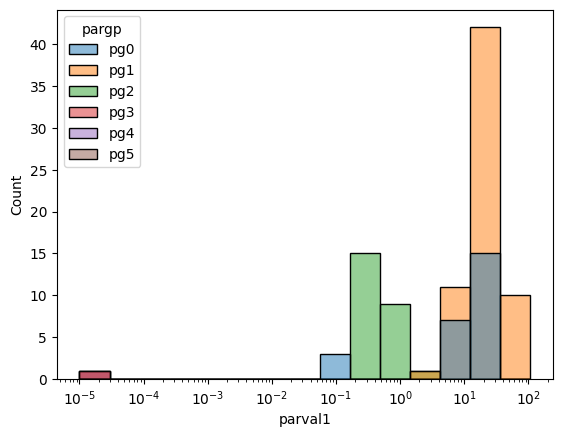

In [115]:
sns.histplot(data=pst.parameter_data, x='parval1', hue='pargp', bins=15, log_scale=True)

In [116]:
estimated_parameters = pst.parameter_data.copy()
10**(estimated_parameters.loc[estimated_parameters['partrans'] == 'log', 'parval1'])


parnme
p0       3.494053e+12
p1       3.494053e+12
p2       1.760332e+14
p3       4.922090e+06
p4       1.433442e+00
p5       3.494053e+12
p6       3.494053e+12
p7       1.760332e+14
p8       4.922090e+06
p9       1.433442e+00
p10      3.494053e+12
p11      3.494053e+12
p12      1.760332e+14
p13      4.922090e+06
p14      1.433442e+00
p15      1.578630e+13
p16      1.578630e+13
p17      3.840001e+13
p18      5.222278e+14
p19      1.468152e+10
p20      2.640122e+17
p21      2.640122e+17
p22      3.551992e+09
p23      2.149429e+06
p24      1.588320e+08
p25      3.473129e+17
p26      6.690378e+13
p27      4.205223e+21
p28      8.174527e+16
p29      3.049961e+06
p30      1.097404e+15
p31      6.237933e+17
p32      3.143095e+11
p33      4.361470e+20
p34      2.330885e+18
p35      5.433550e+13
p36      2.651687e+17
p37     9.818553e+106
p38      3.014681e+21
p39      3.592121e+15
p40      4.697463e+11
p41      4.420554e+26
p42      2.989089e+18
p43      3.232599e+26
p44      2.096574e+17
p45

plotting head results

In [117]:
res_nz = pst.res.loc[pst.nnz_obs_names,:]
# display res_nz to understand what we are doing
res_nz.head(4)

,name,group,measured,modelled,residual,weight
name,,,,,,
ob0,ob0,ob1,0.010999,0.020066,-0.009066,1.0
ob1,ob1,ob1,0.022082,0.022403,-0.000320,1.0
ob2,ob2,ob1,0.037808,0.023504,0.014304,1.0
ob3,ob3,ob1,0.049898,0.023505,0.026394,1.0


<Figure size 800x1050 with 0 Axes>

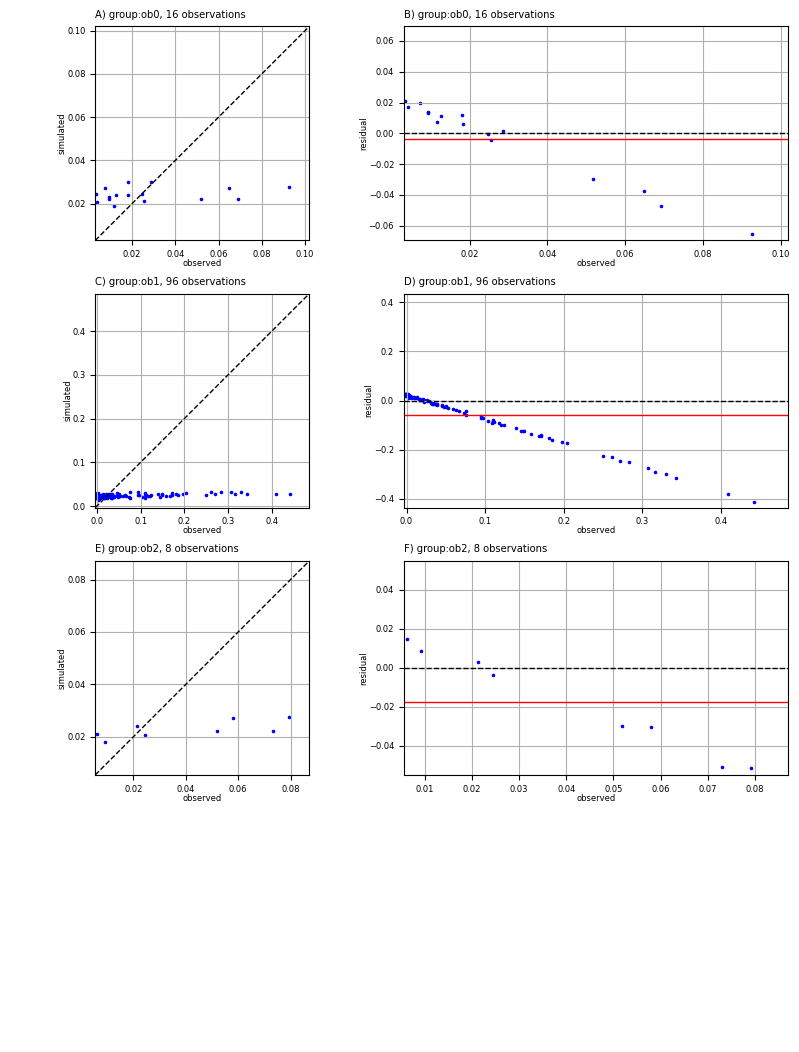

In [118]:
pyemu.plot_utils.res_1to1(pst);

In [119]:
pst.phi

np.float64(1.2594229968101198)

plotting estimated K field

In [120]:
sim_path = os.path.join(m_d, "3d_injection_modeling_PMW-3")
sim = flopy.mf6.MFSimulation.load(sim_ws=sim_path)
gwf = sim.get_model()

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package mlac-model...


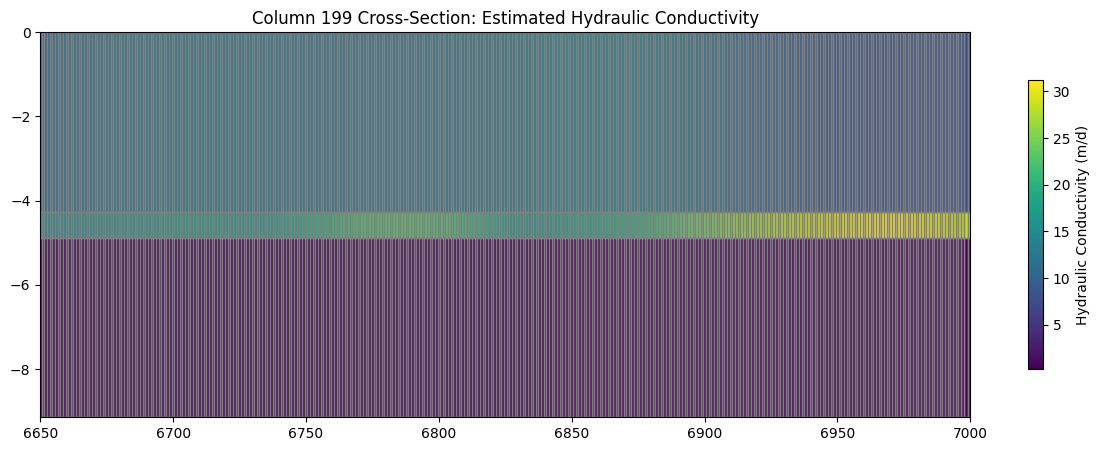

In [121]:
hk_array = gwf.npf.k.array

fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(1, 1, 1)

# Create a PlotCrossSection object for a specific column
xsect = flopy.plot.PlotCrossSection(model=gwf, ax=ax, line={"Column": 199})

# Plot the hydraulic conductivity array on the cross-section
# The plot_array() method will display the values as colored patches
csa = xsect.plot_array(hk_array)

# Plot the model grid for context
linecollection = xsect.plot_grid()

# Add a color bar to interpret the hydraulic conductivity values
cb = plt.colorbar(csa, shrink=0.75, label="Hydraulic Conductivity (m/d)")

# Set the title and show the plot
ax.set_title("Column 199 Cross-Section: Estimated Hydraulic Conductivity")
ax.set_xlim(6650, 7000) # Assuming the same x-limits as your previous plot
plt.show()

whole field

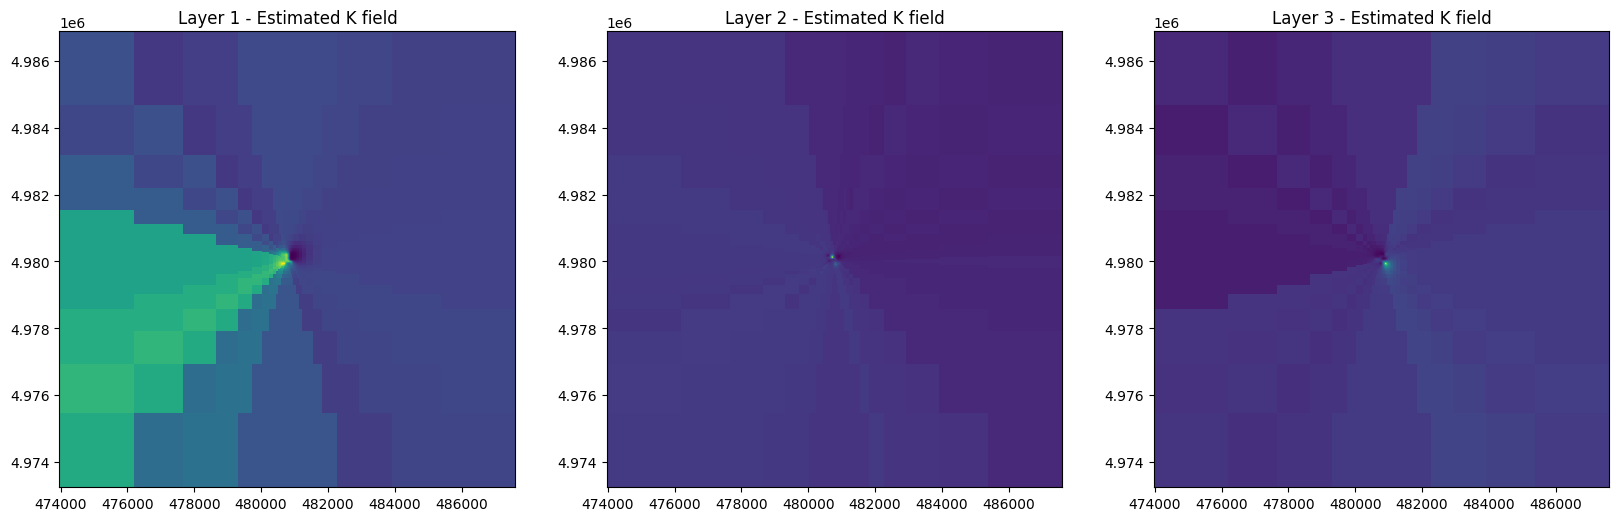

In [122]:
fig = plt.figure(figsize=(20, 20))
for i in range(3):
    
    ax = fig.add_subplot(1, 3, i+1, aspect='equal')

    # Create a PlotMapView object
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)

    # Plot the active and inactive cells
    # In MODFLOW 6, 'IDOMAIN' array is used instead of 'IBOUND'.
    # plot_ibound() handles this automatically.
    quadmesh = mapview.plot_array(hk_array[i]) # plots K field

    # Plot the grid lines for context
    #grid_lines = mapview.plot_grid()

    # Add a title and show the plot
    ax.set_title(f"Layer {i+1} - Estimated K field")
    #plt.show()

zoom at MLAC site

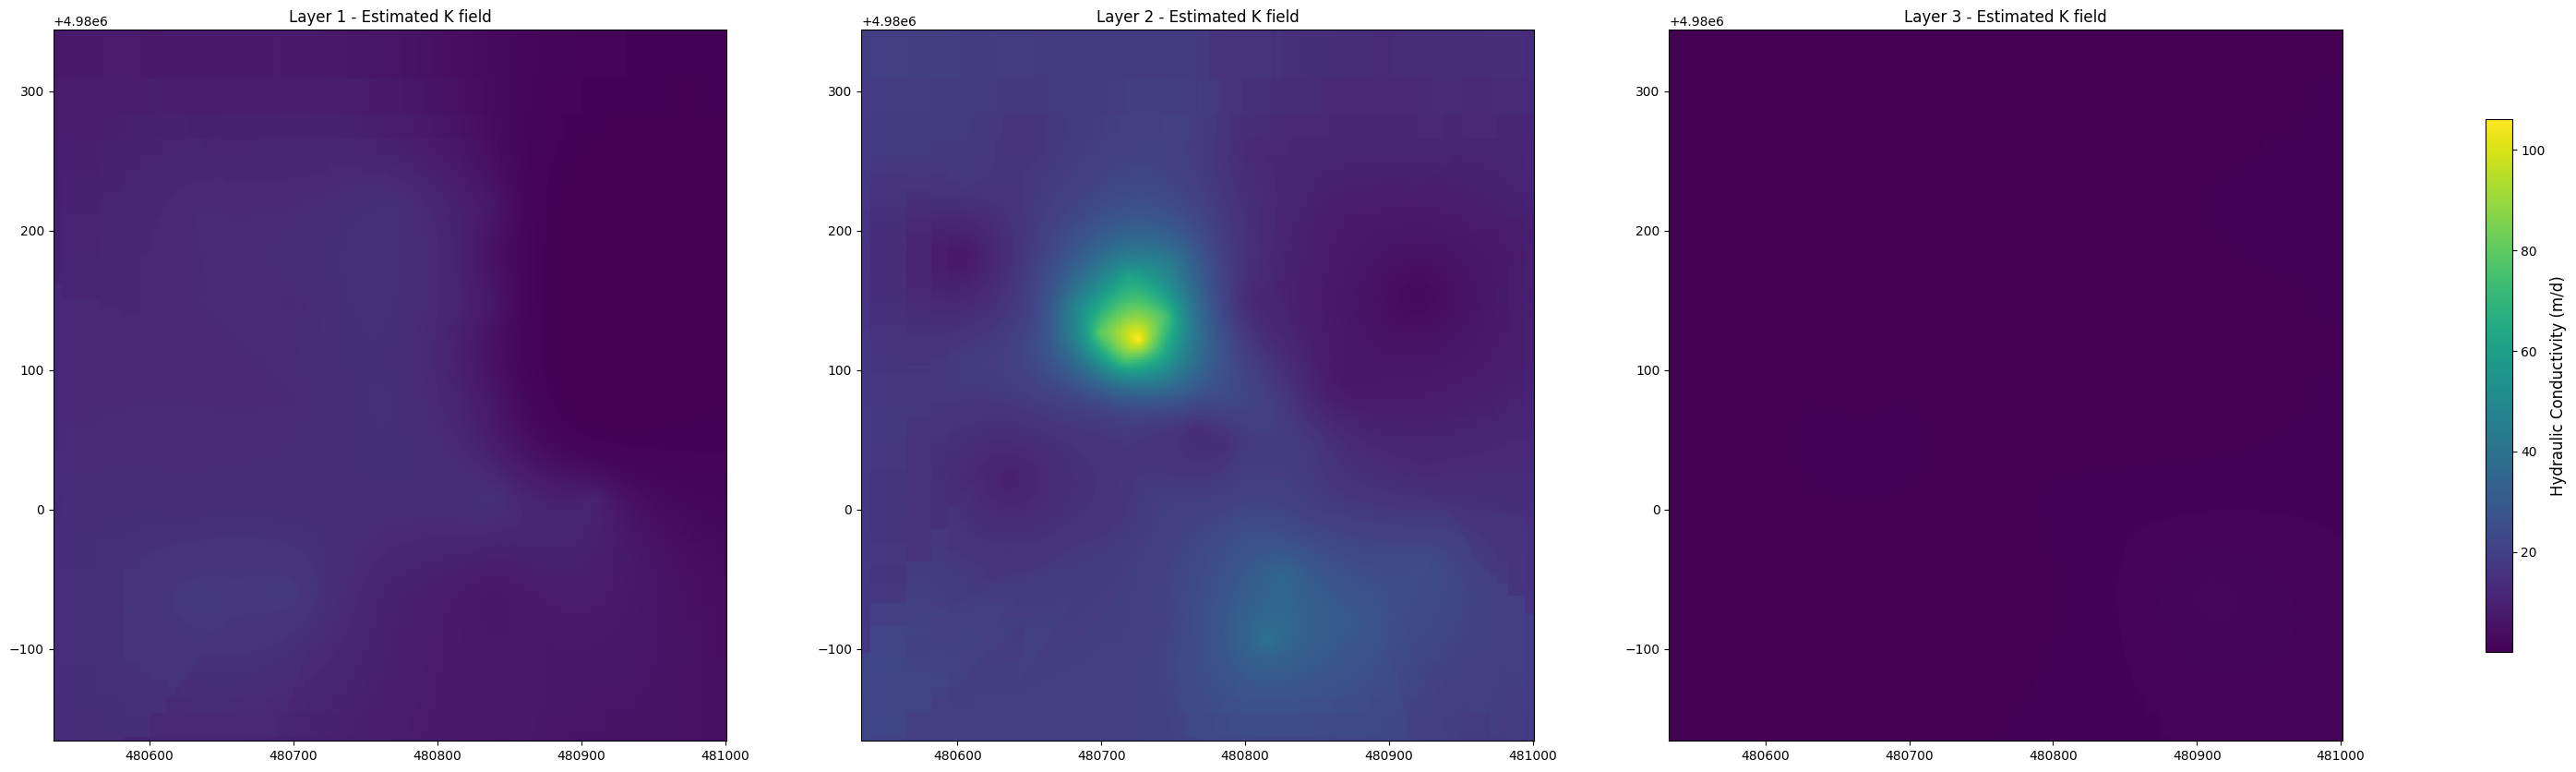

In [123]:
fig, axes = plt.subplots(1, 3, figsize=(40,10))

# Optionally, determine common vmin and vmax for consistent color scaling
vmin = hk_array.min()
vmax = hk_array.max()

# Plot each layer
quadmesh_list = []
for i, ax in enumerate(axes):
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)
    quadmesh = mapview.plot_array(hk_array[i], vmin=vmin, vmax=vmax)
    quadmesh_list.append(quadmesh)  # Store QuadMesh for reference
    ax.set_title(f"Layer {i+1} - Estimated K field")
    ax.set_xlim(480533, 481001)
    ax.set_ylim(4979834, 4980344)
    # Optionally add grid lines
    # mapview.plot_grid()

# Add a single colorbar for all subplots
cbar = fig.colorbar(quadmesh_list[0], ax=axes, shrink=0.75, label="Hydraulic Conductivity (m/d)")
cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=12)

plt.show()

In [124]:
from matplotlib.colors import LogNorm 

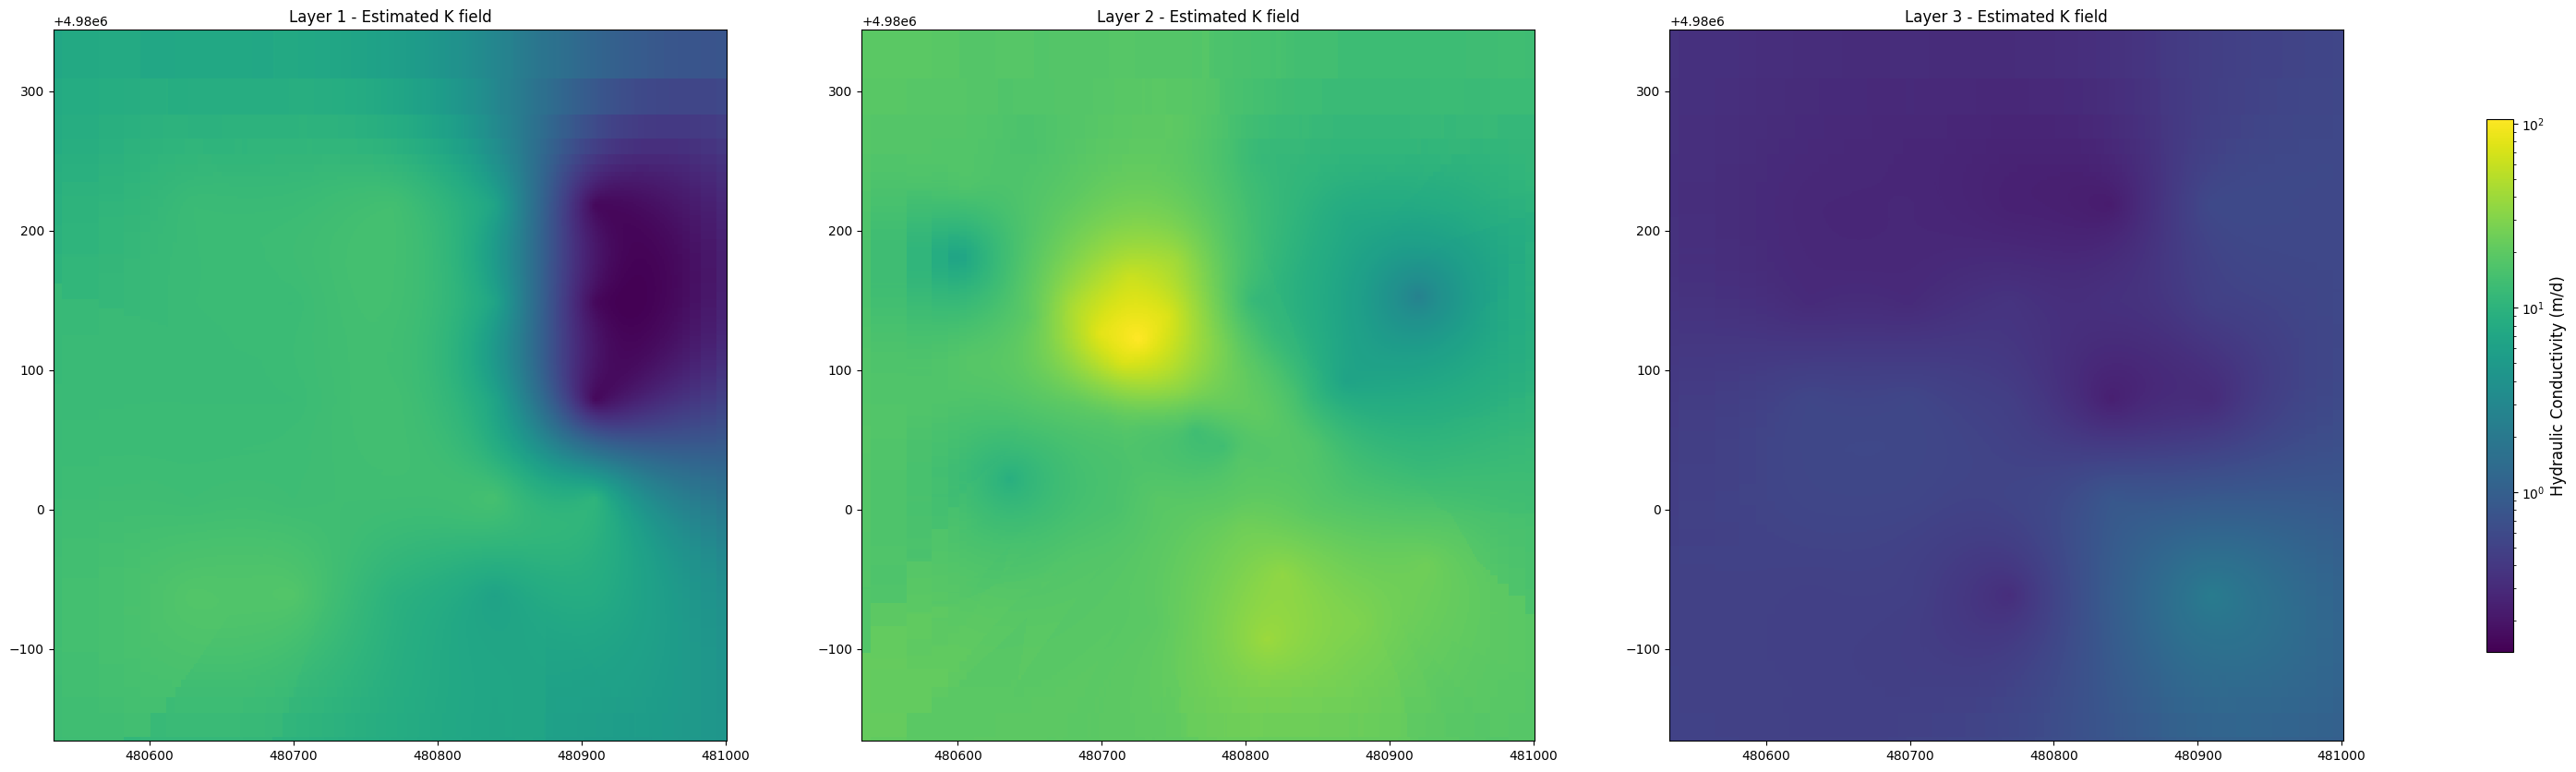

In [125]:
fig, axes = plt.subplots(1, 3, figsize=(40,10))

# Optionally, determine common vmin and vmax for consistent color scaling
# These values MUST be positive for a log scale to work
vmin = hk_array.min()
vmax = hk_array.max()

# Ensure vmin is greater than 0, which hydraulic conductivity should be
if vmin <= 0:
    print(f"Warning: vmin ({vmin}) is <= 0. Adjusting to a small positive value for log scaling.")
    vmin = 1e-3 # Or some other appropriate small positive number

# Define the logarithmic normalization object
norm = LogNorm(vmin=vmin, vmax=vmax)

# Plot each layer
quadmesh_list = []
for i, ax in enumerate(axes):
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)
    
    # Pass the 'norm' object to plot_array()
    quadmesh = mapview.plot_array(hk_array[i], norm=norm) 
    
    quadmesh_list.append(quadmesh)  # Store QuadMesh for reference
    ax.set_title(f"Layer {i+1} - Estimated K field")
    ax.set_xlim(480533, 481001)
    ax.set_ylim(4979834, 4980344)
    # Optionally add grid lines
    # mapview.plot_grid()

# Add a single colorbar for all subplots
# The colorbar automatically uses the norm associated with the quadmesh
cbar = fig.colorbar(quadmesh_list[0], ax=axes, shrink=0.75, label="Hydraulic Conductivity (m/d)")
cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=12)

plt.show()

Adjusting observation weights (this need to be done after running a initial inversion NONPT = 0)

example that used this: https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024WR038048?af=R#:~:text=The%20outcomes%20of%20the%20event,the%20desired%20balance%20is%20obtained.

In [126]:
pst.nnz_obs_groups

['ob1', 'ob0', 'ob2']

In [127]:
balanced_groups = {grp:10 for grp in pst.nnz_obs_groups}
balanced_groups


{'ob1': 10, 'ob0': 10, 'ob2': 10}

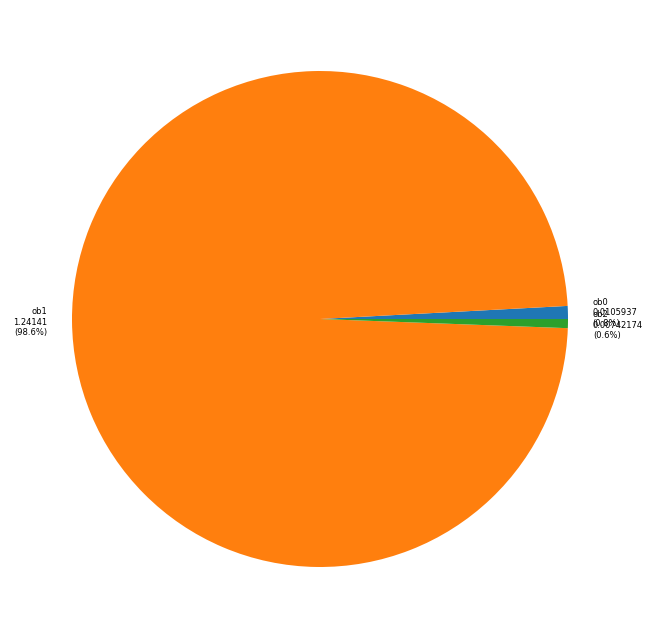

In [128]:
pst.plot(kind="phi_pie");

In [129]:
pst.adjust_weights(obsgrp_dict=balanced_groups,)

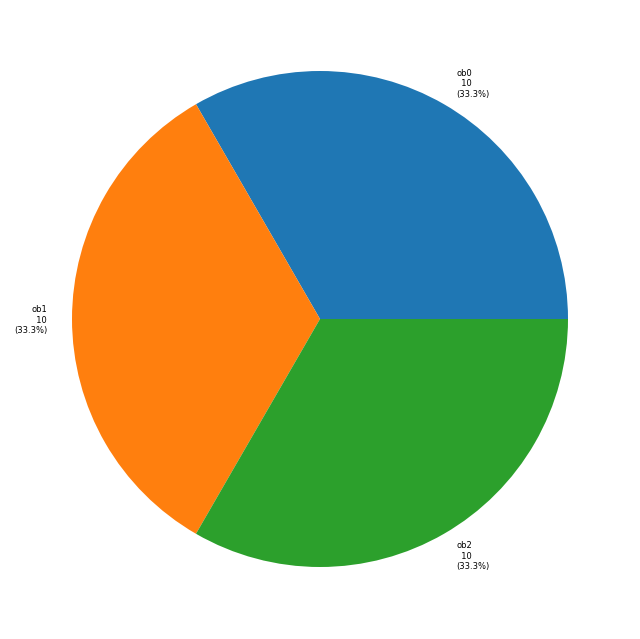

In [130]:
pst.plot(kind="phi_pie");

In [131]:
pst.control_data.noptmax = 20
pst.control_data.noptmax

np.int32(20)

In [132]:
pst.write(os.path.join(m_d, 'mf6.pst'),version=1)

noptmax:20, npar_adj:117, nnz_obs:120


In [133]:
m_d2 = 'master_pp2'

In [134]:
import pyemu

In [135]:
pyemu.os_utils.start_workers(m_d, # folder which contains the "template" PEST dataset
                            'pestpp-glm', #PEST software version we want to run
                            'mf6.pst', #PEST control file 
                            num_workers=num_workers, #how many agents to deploy
                            worker_root='.', #where to deploy the agent directories; relative to where python is running
                            master_dir=m_d2, #manager directory where it will be running
                            verbose=True,
                            )

2025-12-02 16:27:45,551 - MainProcess - INFO - Reserved port 4564 for process 20156


master:pestpp-glm mf6.pst /h :4564 in master_pp2
worker:pestpp-glm mf6.pst /h localhost:4564 in .\worker_0
worker:pestpp-glm mf6.pst /h localhost:4564 in .\worker_1
worker:pestpp-glm mf6.pst /h localhost:4564 in .\worker_2
worker:pestpp-glm mf6.pst /h localhost:4564 in .\worker_3
worker:pestpp-glm mf6.pst /h localhost:4564 in .\worker_4
worker:pestpp-glm mf6.pst /h localhost:4564 in .\worker_5
worker:pestpp-glm mf6.pst /h localhost:4564 in .\worker_6
worker:pestpp-glm mf6.pst /h localhost:4564 in .\worker_7
worker:pestpp-glm mf6.pst /h localhost:4564 in .\worker_8


Checking results

In [136]:
df_obj = pd.read_csv(os.path.join(m_d2, "mf6.iobj"),index_col=0)
# echo out the dataframe
df_obj

,model_runs_completed,total_phi,measurement_phi,regularization_phi,ob1,ob0,ob2,regulpg0,regulpg1,regulpg2
iteration,,,,,,,,,,
0,0,30.0000,30.0000,5.853380e-16,10.00000,10.00000,10.00000,1.951130e-16,1.951130e-16,1.951130e-16
1,132,26.5982,26.5972,1.046970e-03,9.46764,9.29124,7.83831,5.581600e-04,4.813560e-04,7.454380e-06
2,207,25.0351,25.0256,9.564750e-03,9.08445,9.32254,6.61859,4.338720e-06,5.472720e-06,9.554940e-03
3,455,24.5165,24.5165,2.304030e-07,9.03420,8.92272,6.55962,7.822230e-08,7.099710e-08,8.118400e-08
4,676,24.2948,24.2948,3.202600e-09,8.80065,8.69277,6.80133,8.555890e-10,1.028220e-09,1.318790e-09
5,893,24.0867,24.0867,1.211100e-10,8.68420,8.60837,6.79411,3.971610e-11,4.100290e-11,4.039080e-11
6,1111,24.3758,24.3758,1.578280e-10,8.73397,8.66745,6.97442,5.242920e-11,5.273000e-11,5.266880e-11
7,1342,24.3942,24.3942,1.218480e-10,8.74487,8.64462,7.00470,4.069060e-11,4.054070e-11,4.061660e-11
8,1569,24.2700,24.2700,1.217660e-10,8.73517,8.59506,6.93973,4.059510e-11,4.058920e-11,4.058170e-11


array([<Axes: xlabel='iteration'>, <Axes: xlabel='iteration'>],
      dtype=object)

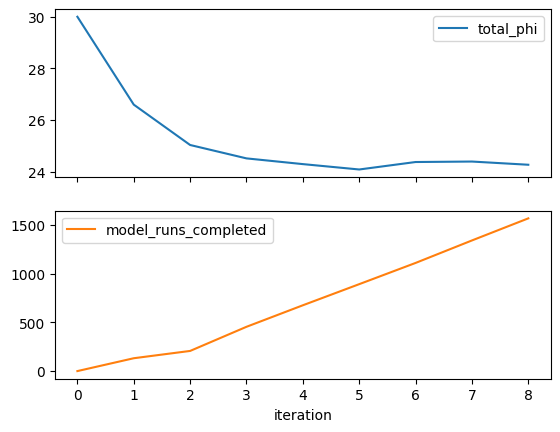

In [137]:
df_obj.loc[:,["total_phi","model_runs_completed"]].plot(subplots=True)

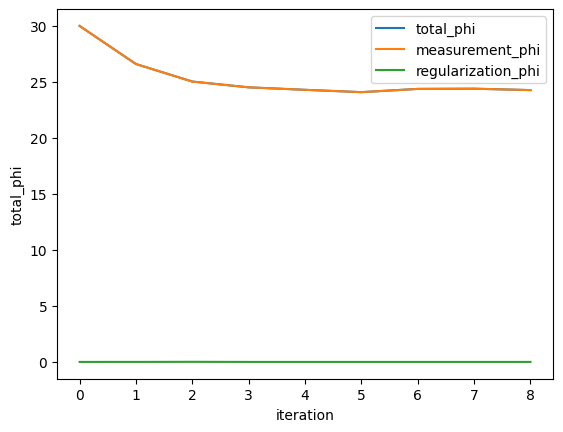

In [138]:
df_obj.plot(y=['total_phi','measurement_phi','regularization_phi'])
plt.ylabel('total_phi');
#plt.yscale("log")

In [139]:
pst = pyemu.Pst(os.path.join(m_d2, 'mf6.pst'))

In [140]:
pst.control_data.rlambda1

1.0

In [141]:
pst.parrep(os.path.join(m_d2, "mf6.par" ))
pst.write_input_files(pst_path=m_d2)
pyemu.geostats.fac2real(os.path.join(m_d2,"k_layer1_inst0pp.dat"),
                        factors_file=os.path.join(m_d2,"k_layer1_inst0pp.fac"),
                        out_file=os.path.join(m_d2,"k_layer1.txt"))

Updating parameter values from master_pp2\mf6.par
parrep: updating noptmax to 0


'master_pp2\\k_layer1.txt'

In [142]:
pyemu.geostats.fac2real(os.path.join(m_d2,"k_layer2_inst0pp.dat"),
                        factors_file=os.path.join(m_d2,"k_layer2_inst0pp.fac"),
                        out_file=os.path.join(m_d2,"k_layer2.txt"))

'master_pp2\\k_layer2.txt'

In [143]:
pyemu.geostats.fac2real(os.path.join(m_d2,"k_layer3_inst0pp.dat"),
                        factors_file=os.path.join(m_d2,"k_layer1_inst0pp.fac"),
                        out_file=os.path.join(m_d2,"k_layer3.txt"))

'master_pp2\\k_layer3.txt'

In [144]:
pst.parameter_data.parval1

parnme
p0         1.071175
p1         7.468675
p2        80.212499
p3         0.484326
p4         0.365275
p5        10.204997
p6         0.255859
p7        52.819030
p8        22.806791
p9         0.352319
p10       30.848248
p11       16.922437
p12        1.617086
p13        0.669059
p14        1.261570
p15      163.207898
p16        4.182910
p17       25.956100
p18        5.565149
p19        2.696699
p20       14.820732
p21       69.688220
p22        5.669382
p23        1.329661
p24       29.073081
p25      570.758913
p26       42.157776
p27        1.654210
p28       10.315938
p29       11.860051
p30       24.493131
p31       46.379745
p32       33.159498
p33        0.665290
p34     2142.757955
p35        0.286189
p36        3.350921
p37       84.091982
p38        0.261270
p39        2.588979
p40       13.417286
p41       31.426621
p42        2.915550
p43       22.972914
p44        7.245585
p45       46.139251
p46        7.951023
p47      111.784953
p48       21.760801
p49        0.

<Axes: >

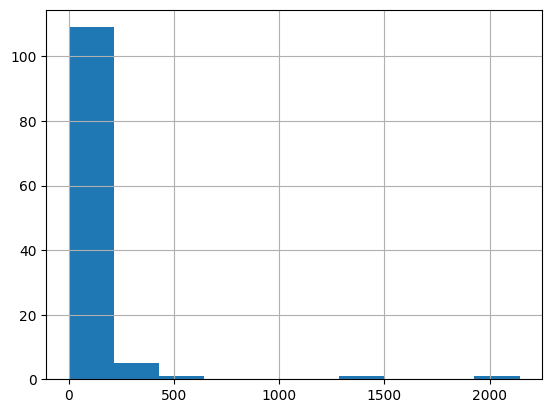

In [145]:
import seaborn as sns
pst.parameter_data.parval1.hist()

In [146]:
pst.parameter_data

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,extra,longname,i,inst,j,pname,pstyle,ptype,x,y,zone
parnme,,,,,,,,,,,,,,,,,,,,,
p0,p0,log,factor,1.071175,0.031977,3.577192e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,35,0,35,k,m,pp,NaN,NaN,1
p1,p1,log,factor,7.468675,0.031977,3.577192e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,35,0,105,k,m,pp,NaN,NaN,1
p2,p2,log,factor,80.212499,0.042864,4.795136e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,35,0,175,k,m,pp,NaN,NaN,1
p3,p3,log,factor,0.484326,0.007526,8.419539e+05,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,35,0,245,k,m,pp,NaN,NaN,1
p4,p4,log,factor,0.365275,0.000001,1.475322e+02,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,35,0,315,k,m,pp,NaN,NaN,1
p5,p5,log,factor,10.204997,0.031977,3.577192e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:35_zone:1,105,0,35,k,m,pp,NaN,NaN,1
p6,p6,log,factor,0.255859,0.031977,3.577192e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:105_zone:1,105,0,105,k,m,pp,NaN,NaN,1
p7,p7,log,factor,52.819030,0.042864,4.795136e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:175_zone:1,105,0,175,k,m,pp,NaN,NaN,1
p8,p8,log,factor,22.806791,0.007526,8.419539e+05,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:245_zone:1,105,0,245,k,m,pp,NaN,NaN,1


<Axes: xlabel='parval1', ylabel='Count'>

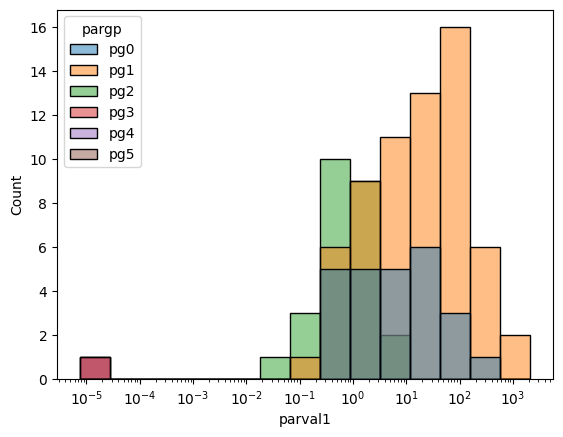

In [147]:
sns.histplot(data=pst.parameter_data, x='parval1', hue='pargp', bins=15, log_scale=True)

In [148]:
res_nz = pst.res.loc[pst.nnz_obs_names,:]
# display res_nz to understand what we are doing
res_nz

,name,group,measured,modelled,residual,weight
name,,,,,,
ob0,ob0,ob1,0.010999,0.030328,-0.019329,2.838199
ob1,ob1,ob1,0.022082,0.034237,-0.012154,2.838199
ob2,ob2,ob1,0.037808,0.037499,0.000309,2.838199
ob3,ob3,ob1,0.049898,0.038940,0.010959,2.838199
ob4,ob4,ob1,0.006916,0.028073,-0.021156,2.838199
ob5,ob5,ob1,0.021499,0.031927,-0.010428,2.838199
ob6,ob6,ob1,0.039108,0.035120,0.003988,2.838199
ob7,ob7,ob1,0.052965,0.036521,0.016444,2.838199
ob8,ob8,ob1,0.003417,0.026149,-0.022733,2.838199


<Figure size 800x1050 with 0 Axes>

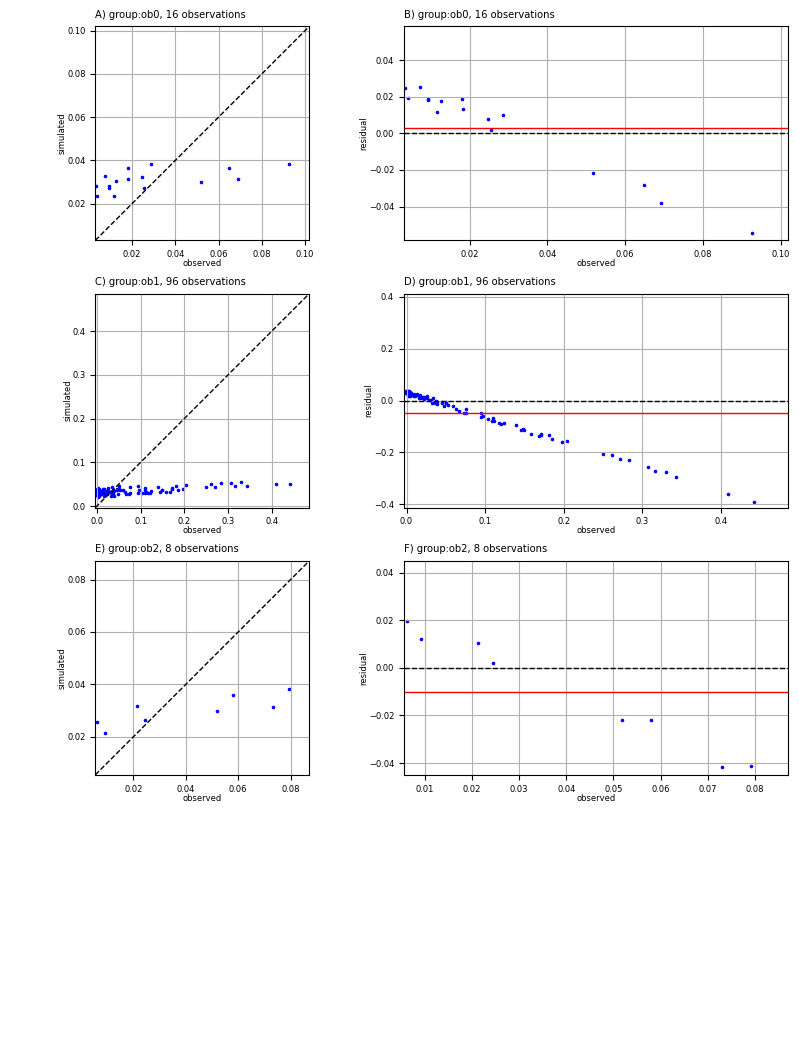

In [149]:
pyemu.plot_utils.res_1to1(pst);

In [150]:
sim_path = os.path.join(m_d2, "3d_injection_modeling_PMW-3")
sim = flopy.mf6.MFSimulation.load(sim_ws=sim_path)
gwf = sim.get_model()

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package mlac-model...


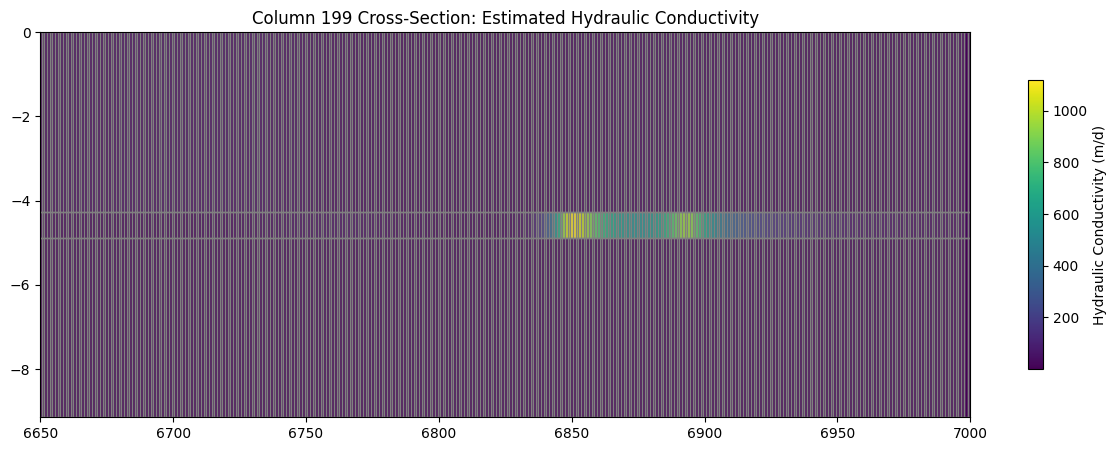

In [151]:
hk_array = gwf.npf.k.array

fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(1, 1, 1)

# Create a PlotCrossSection object for a specific column
xsect = flopy.plot.PlotCrossSection(model=gwf, ax=ax, line={"Column": 199})

# Plot the hydraulic conductivity array on the cross-section
# The plot_array() method will display the values as colored patches
csa = xsect.plot_array(hk_array)

# Plot the model grid for context
linecollection = xsect.plot_grid()

# Add a color bar to interpret the hydraulic conductivity values
cb = plt.colorbar(csa, shrink=0.75, label="Hydraulic Conductivity (m/d)")

# Set the title and show the plot
ax.set_title("Column 199 Cross-Section: Estimated Hydraulic Conductivity")
ax.set_xlim(6650, 7000) # Assuming the same x-limits as your previous plot
plt.show()

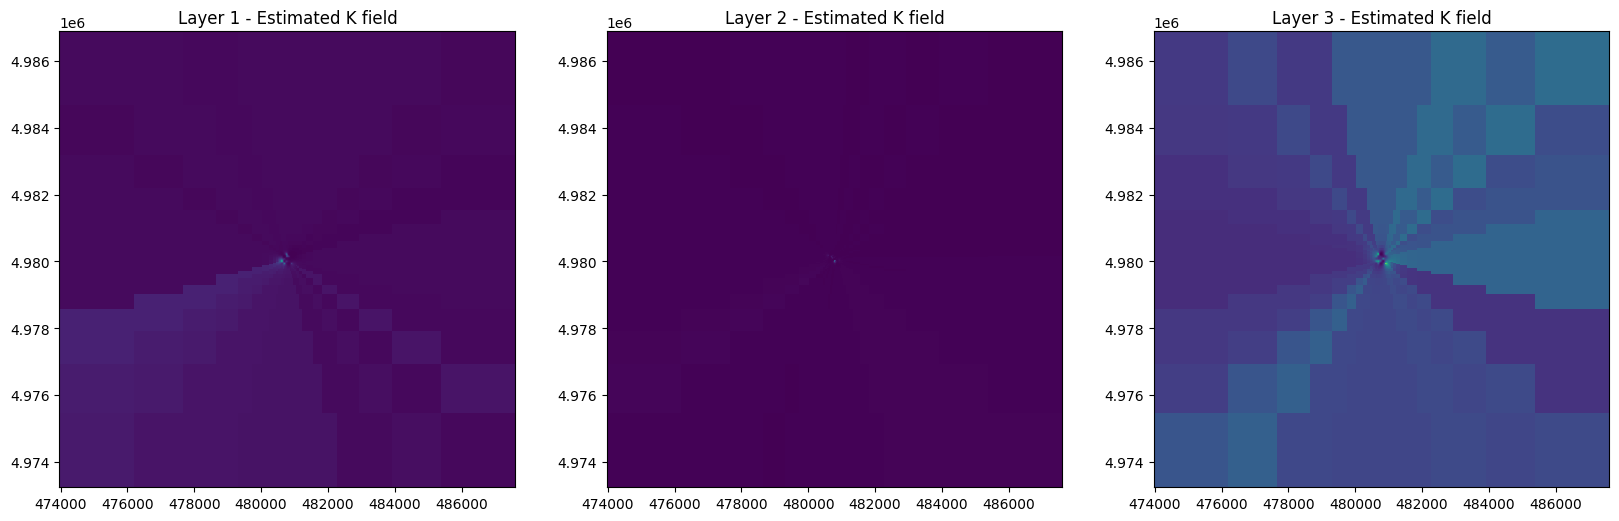

In [152]:
fig = plt.figure(figsize=(20, 20))
for i in range(3):
    
    ax = fig.add_subplot(1, 3, i+1, aspect='equal')

    # Create a PlotMapView object
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)

    # Plot the active and inactive cells
    # In MODFLOW 6, 'IDOMAIN' array is used instead of 'IBOUND'.
    # plot_ibound() handles this automatically.
    quadmesh = mapview.plot_array(hk_array[i]) # plots K field

    # Plot the grid lines for context
    #grid_lines = mapview.plot_grid()

    # Add a title and show the plot
    ax.set_title(f"Layer {i+1} - Estimated K field")
    #plt.show()

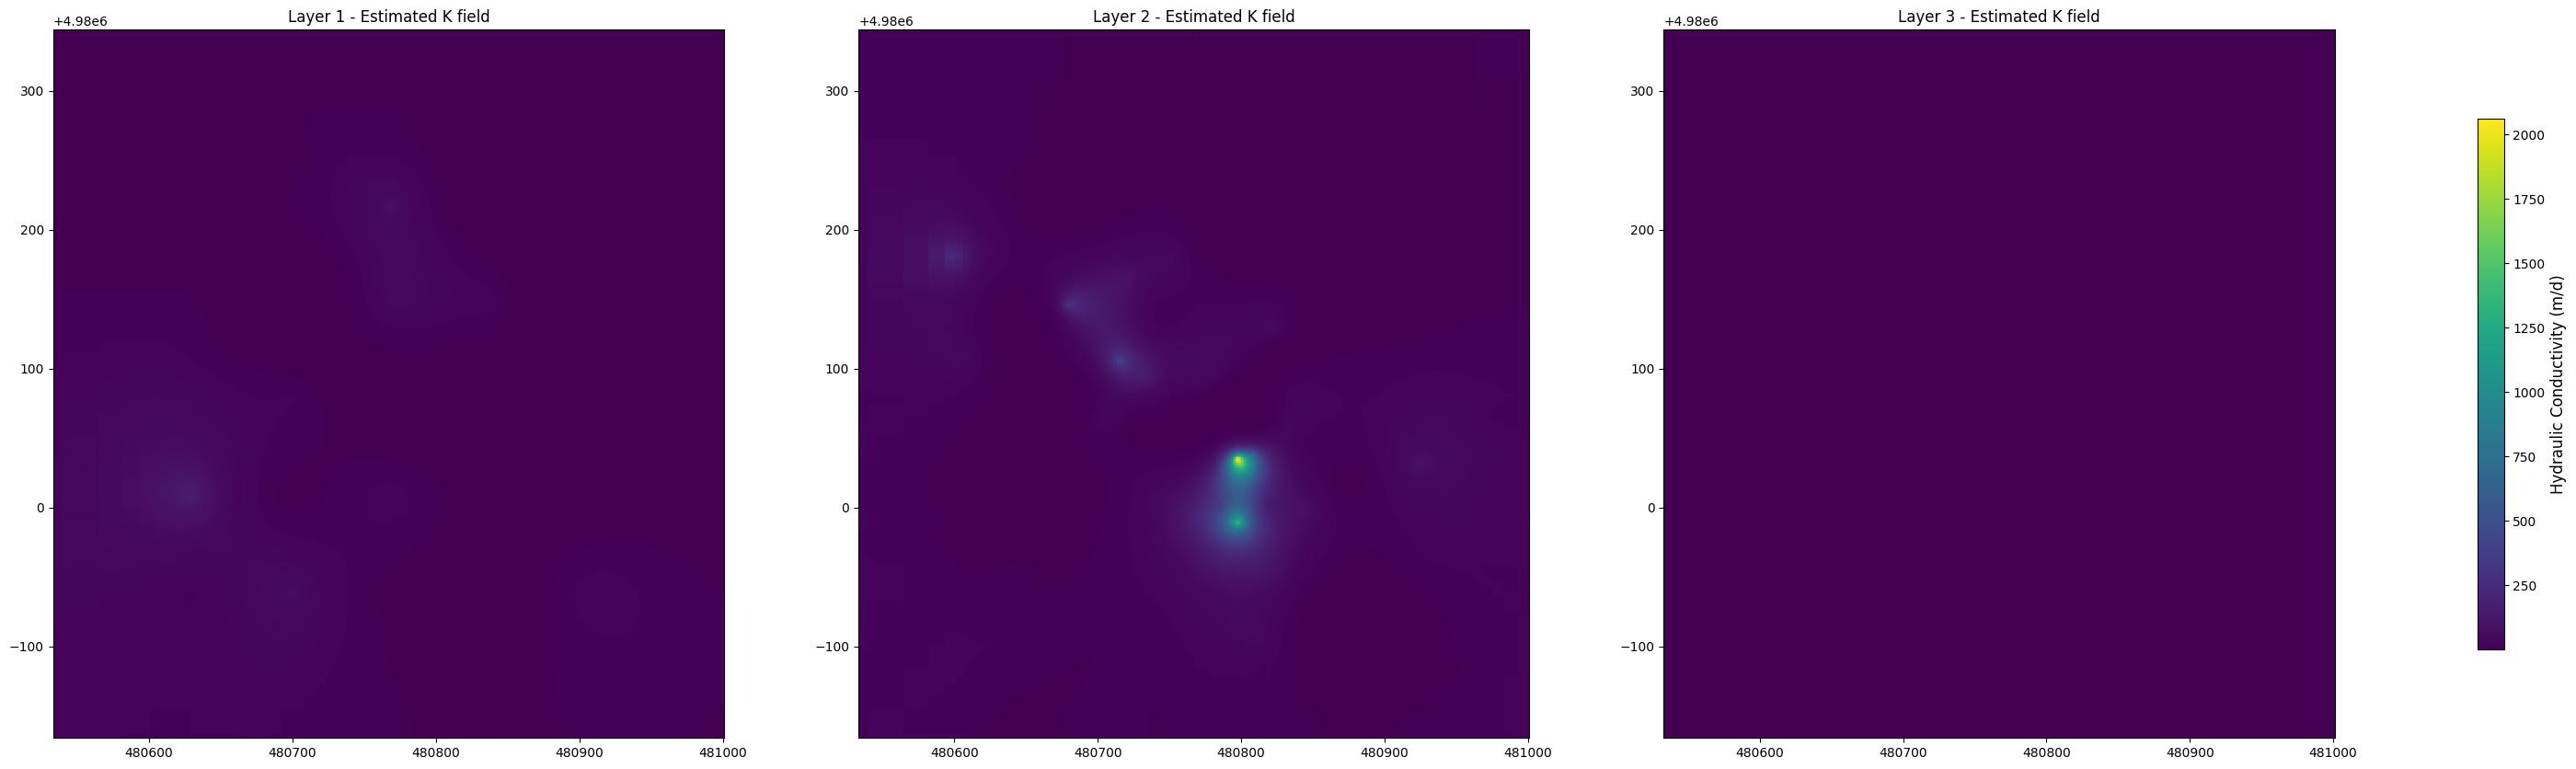

In [153]:
fig, axes = plt.subplots(1, 3, figsize=(40,10))

# Optionally, determine common vmin and vmax for consistent color scaling
vmin = hk_array.min()
vmax = hk_array.max()

# Plot each layer
quadmesh_list = []
for i, ax in enumerate(axes):
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)
    quadmesh = mapview.plot_array(hk_array[i], vmin=vmin, vmax=vmax)
    quadmesh_list.append(quadmesh)  # Store QuadMesh for reference
    ax.set_title(f"Layer {i+1} - Estimated K field")
    ax.set_xlim(480533, 481001)
    ax.set_ylim(4979834, 4980344)
    # Optionally add grid lines
    # mapview.plot_grid()

# Add a single colorbar for all subplots
cbar = fig.colorbar(quadmesh_list[0], ax=axes, shrink=0.75, label="Hydraulic Conductivity (m/d)")
cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=12)

plt.show()

In [154]:
from matplotlib.colors import LogNorm 

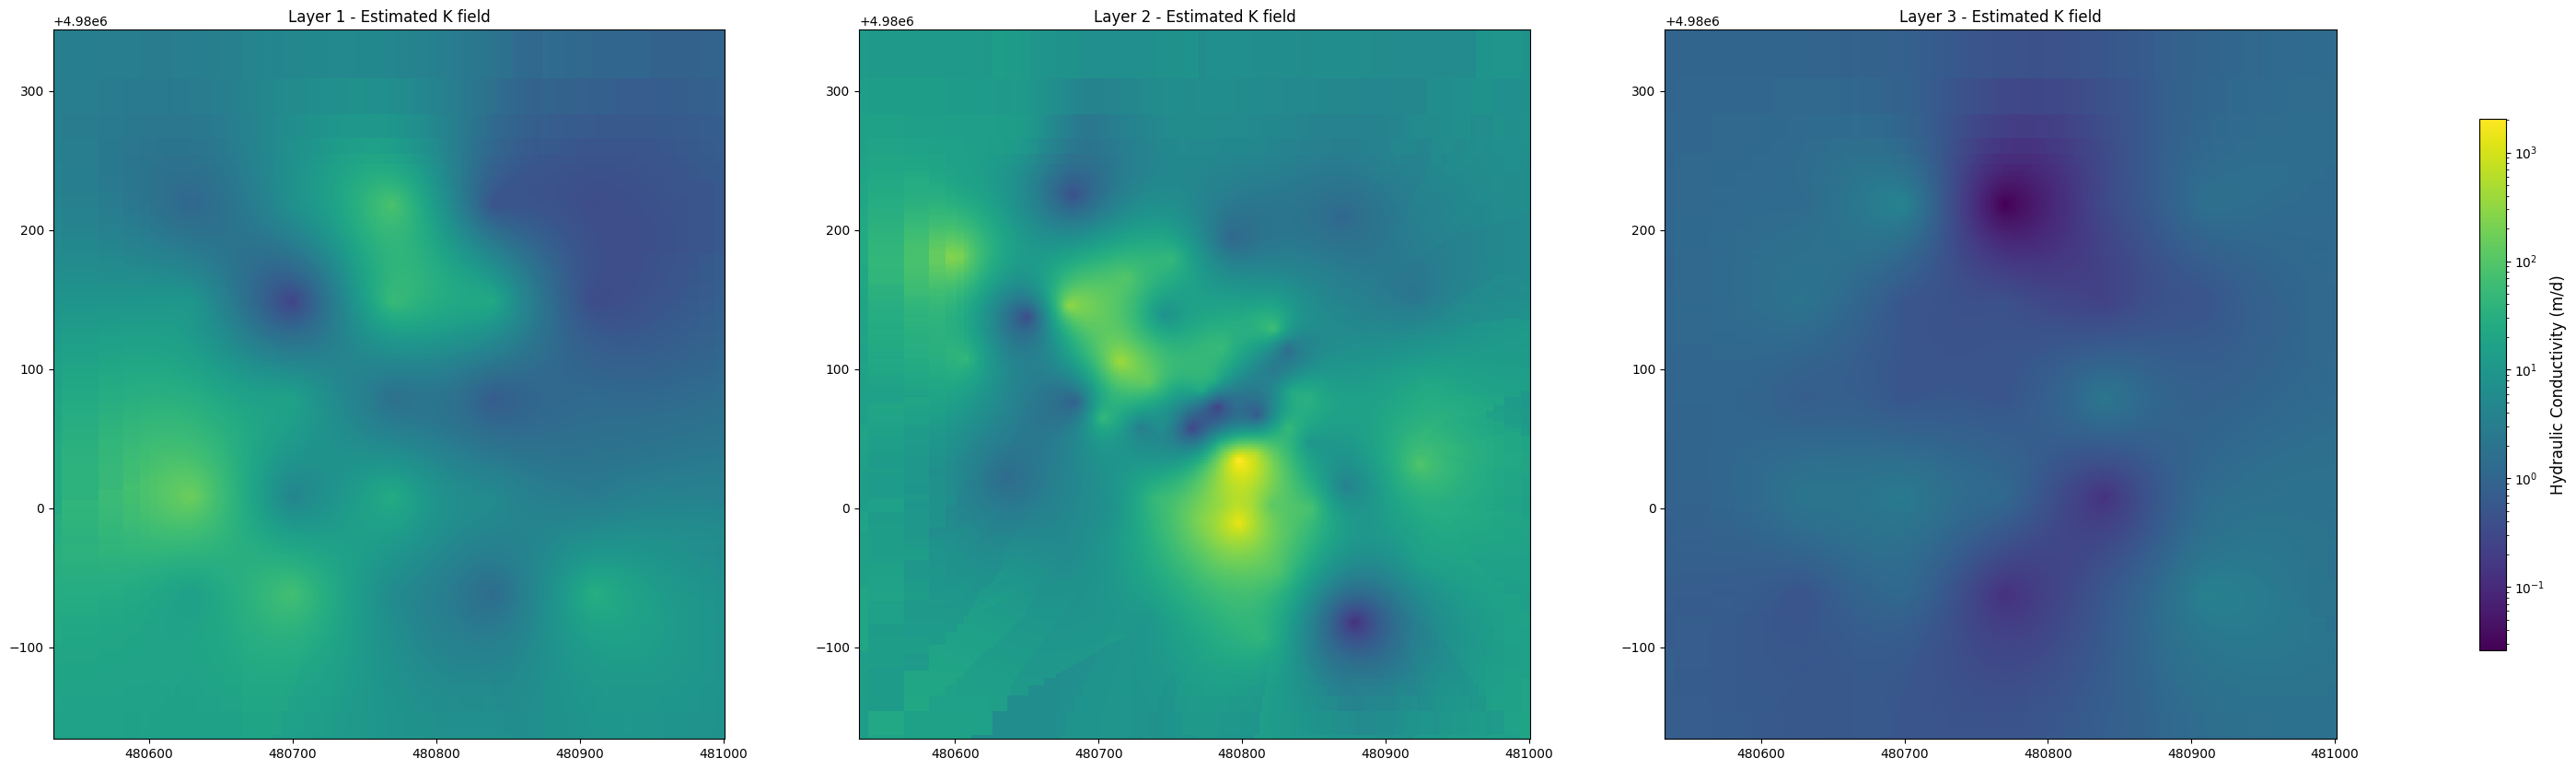

In [155]:
fig, axes = plt.subplots(1, 3, figsize=(40,10))

# Optionally, determine common vmin and vmax for consistent color scaling
# These values MUST be positive for a log scale to work
vmin = hk_array.min()
vmax = hk_array.max()

# Ensure vmin is greater than 0, which hydraulic conductivity should be
if vmin <= 0:
    print(f"Warning: vmin ({vmin}) is <= 0. Adjusting to a small positive value for log scaling.")
    vmin = 1e-3 # Or some other appropriate small positive number

# Define the logarithmic normalization object
norm = LogNorm(vmin=vmin, vmax=vmax)

# Plot each layer
quadmesh_list = []
for i, ax in enumerate(axes):
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)
    
    # Pass the 'norm' object to plot_array()
    quadmesh = mapview.plot_array(hk_array[i], norm=norm) 
    
    quadmesh_list.append(quadmesh)  # Store QuadMesh for reference
    ax.set_title(f"Layer {i+1} - Estimated K field")
    ax.set_xlim(480533, 481001)
    ax.set_ylim(4979834, 4980344)
    # Optionally add grid lines
    # mapview.plot_grid()

# Add a single colorbar for all subplots
# The colorbar automatically uses the norm associated with the quadmesh
cbar = fig.colorbar(quadmesh_list[0], ax=axes, shrink=0.75, label="Hydraulic Conductivity (m/d)")
cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=12)

plt.show()

debugging

In [1]:
import pathlib as pl 
import warnings
import flopy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

c:\Users\lima0055\anaconda3\envs\gmdsitut\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
